In [ ]:
pip install wntr

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import wntr
import os
import shutil
import zipfile
import re
from pathlib import Path
from collections import Counter, defaultdict
import scipy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import copy
import time
import torch.optim as optim
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)

Using device: cuda
GPU: Tesla T4
CUDA version: 12.8


In [2]:
print("NumPy :", np.__version__)
print("SciPy :", scipy.__version__)
print("WNTR  :", wntr.__version__)

print("\nAll imports successful.")

NumPy : 2.5.2
SciPy : 1.16.3
WNTR  : 1.5.0

All imports successful.


In [3]:
BASE = Path(
    "/kaggle/input/datasets/nishant230408/hanoi-data/HanoiOK"
)

print("BASE exists:", BASE.exists())
print("Scenario folders found:", len(list(BASE.glob("Scenario-*"))))

BASE exists: True
Scenario folders found: 500


In [4]:
BASE = Path("/kaggle/input/datasets/nishant230408/hanoi-data/HanoiOK")

records = []

# ---------- helper: extract coordinates from .inp ----------
def get_coordinates(inp_path):
    coords = {}
    in_coordinates = False

    with open(inp_path, "r", errors="ignore") as f:
        for line in f:
            line = line.strip()

            if line.upper() == "[COORDINATES]":
                in_coordinates = True
                continue

            # Stop when next EPANET section begins
            if in_coordinates and line.startswith("["):
                break

            if not in_coordinates or not line or line.startswith(";"):
                continue

            parts = line.split()

            if len(parts) >= 3:
                try:
                    node_id = parts[0]
                    x = float(parts[1])
                    y = float(parts[2])

                    coords[node_id] = (x, y)
                except ValueError:
                    pass

    return coords


# ---------- loop through scenarios ----------
scenario_dirs = sorted(
    [p for p in BASE.glob("Scenario-*") if p.is_dir()],
    key=lambda p: int(p.name.split("-")[1])
)

print(f"Found {len(scenario_dirs)} scenarios")

for scenario_dir in scenario_dirs:

    scenario_id = int(scenario_dir.name.split("-")[1])

    # Scenario-specific network file
    inp_path = scenario_dir / f"Hanoi_Scenario-{scenario_id}.inp"

    if not inp_path.exists():
        print(f"WARNING: Missing INP for Scenario {scenario_id}")
        continue

    # Extract all node coordinates
    coordinates = get_coordinates(inp_path)

    # Leak files
    leaks_dir = scenario_dir / "Leaks"

    if not leaks_dir.exists():
        print(f"WARNING: No Leaks folder for Scenario {scenario_id}")
        continue

    info_files = sorted(leaks_dir.glob("Leak_*_info.csv"))

    for info_file in info_files:

        # Read leak metadata
        info_df = pd.read_csv(info_file)

        # Convert Description -> Value into dictionary
        info_dict = dict(
            zip(
                info_df.iloc[:, 0].astype(str).str.strip(),
                info_df.iloc[:, 1]
            )
        )

        leak_id = str(info_dict.get("Leak Node", "")).strip()

        if not leak_id:
            print(f"WARNING: Could not find Leak Node in {info_file}")
            continue

        # Exact coordinates of artificial leak node
        x0, y0 = coordinates.get(leak_id, (None, None))

        # Matching demand file
        demand_file = leaks_dir / f"Leak_{leak_id}_demand.csv"

        records.append({
            "scenario": scenario_id,
            "leak_id": leak_id,
            "x0": x0,
            "y0": y0,
            "leak_area": info_dict.get("Leak Area"),
            "leak_diameter": info_dict.get("Leak Diameter"),
            "leak_type": info_dict.get("Leak Type"),
            "leak_start": info_dict.get("Leak Start"),
            "leak_end": info_dict.get("Leak End"),
            "demand_file": str(demand_file),
            "coordinates_found": x0 is not None and y0 is not None
        })


# ---------- final metadata table ----------
leak_metadata = pd.DataFrame(records)

# Convert types
for col in ["x0", "y0", "leak_area", "leak_diameter"]:
    leak_metadata[col] = pd.to_numeric(
        leak_metadata[col],
        errors="coerce"
    )

leak_metadata["leak_start"] = pd.to_datetime(
    leak_metadata["leak_start"],
    errors="coerce"
)

leak_metadata["leak_end"] = pd.to_datetime(
    leak_metadata["leak_end"],
    errors="coerce"
)

print("\n" + "=" * 80)
print("LEAK METADATA EXTRACTION COMPLETE")
print("=" * 80)

print(f"Total leak records: {len(leak_metadata)}")
print(f"Unique scenarios: {leak_metadata['scenario'].nunique()}")
print(f"Missing coordinates: {leak_metadata['coordinates_found'].eq(False).sum()}")
print()

display(leak_metadata.head(10))

print("\nLeak type distribution:")
print(leak_metadata["leak_type"].value_counts())

print("\nLeaks per scenario:")
print(leak_metadata.groupby("scenario").size().value_counts().sort_index())

Found 500 scenarios

LEAK METADATA EXTRACTION COMPLETE
Total leak records: 754
Unique scenarios: 499
Missing coordinates: 0



,scenario,leak_id,x0,y0,leak_area,leak_diameter,leak_type,leak_start,leak_end,demand_file,coordinates_found
0,2,leak_node0,7260.510000,7231.791224,0.001405,0.042294,small,2024-04-24 23:00:00,2024-05-05 11:30:00,/kaggle/input/datasets/nishant230408/hanoi-dat...,True
1,2,leak_node1,6793.220000,8088.173703,0.076565,0.312227,big,2024-08-08 22:00:00,2024-09-16 16:30:00,/kaggle/input/datasets/nishant230408/hanoi-dat...,True
2,3,leak_node0,4550.230000,4910.025702,0.000143,0.013508,small,2024-12-09 07:00:00,2024-12-20 03:30:00,/kaggle/input/datasets/nishant230408/hanoi-dat...,True
3,4,leak_node0,7260.510000,7646.800091,0.020545,0.161737,small,2024-03-28 08:30:00,2024-05-14 17:00:00,/kaggle/input/datasets/nishant230408/hanoi-dat...,True
4,5,leak_node0,2716.120000,6654.563693,0.000750,0.030912,small,2024-04-23 13:00:00,2024-07-07 11:30:00,/kaggle/input/datasets/nishant230408/hanoi-dat...,True
5,5,leak_node1,4297.681937,7990.650000,0.035512,0.212639,big,2024-04-18 14:30:00,2024-10-14 03:00:00,/kaggle/input/datasets/nishant230408/hanoi-dat...,True
6,6,leak_node0,6793.220000,8492.808047,0.004942,0.079328,small,2024-05-20 02:00:00,2024-08-24 20:30:00,/kaggle/input/datasets/nishant230408/hanoi-dat...,True
7,6,leak_node1,6038.456631,7990.650000,0.067394,0.292931,big,2024-01-04 11:30:00,2024-06-22 09:30:00,/kaggle/input/datasets/nishant230408/hanoi-dat...,True
8,7,leak_node0,6757.662468,7990.650000,0.002644,0.058022,small,2024-01-11 01:00:00,2024-07-10 09:00:00,/kaggle/input/datasets/nishant230408/hanoi-dat...,True
9,7,leak_node1,6616.135378,7990.650000,0.003448,0.066259,small,2024-01-15 23:30:00,2024-12-19 20:30:00,/kaggle/input/datasets/nishant230408/hanoi-dat...,True



Leak type distribution:
leak_type
small    385
big      369
Name: count, dtype: int64

Leaks per scenario:
1    244
2    255
Name: count, dtype: int64


In [5]:
inp_path = BASE / "Scenario-1" / "Hanoi_Scenario-1.inp"

wn = wntr.network.WaterNetworkModel(inp_path)

print("Nodes:", len(wn.node_name_list))
print("Links:", len(wn.link_name_list))

Nodes: 32
Links: 34


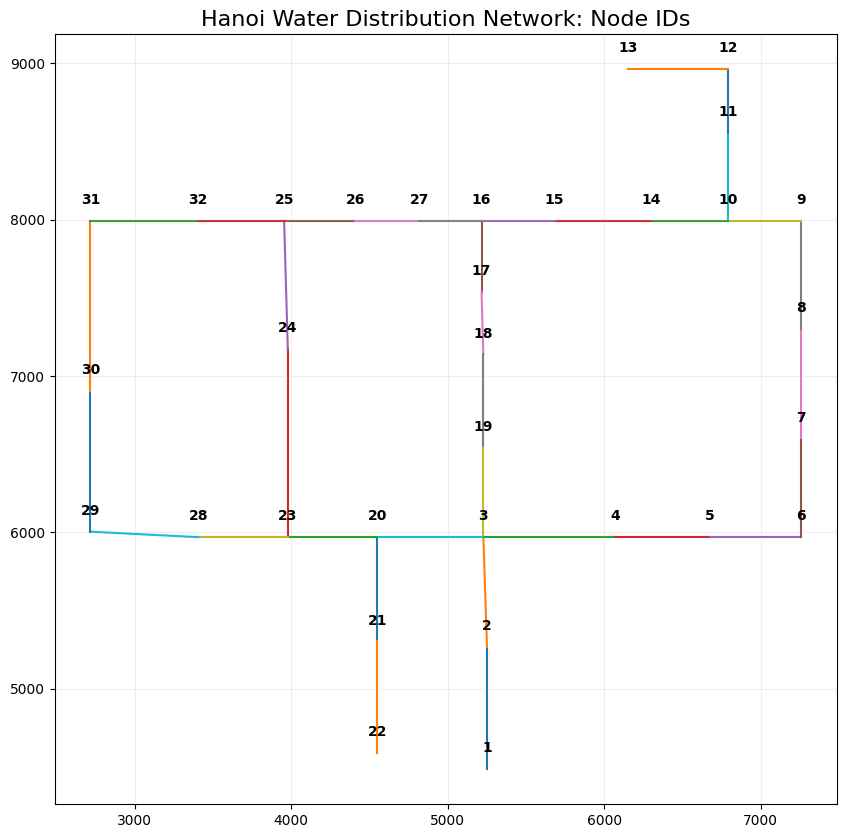

In [6]:
fig, ax = plt.subplots(figsize=(14, 10))

# ---- Draw links manually ----
for link_id in wn.link_name_list:
    link = wn.get_link(link_id)

    start_node = wn.get_node(link.start_node_name)
    end_node = wn.get_node(link.end_node_name)

    x1, y1 = start_node.coordinates
    x2, y2 = end_node.coordinates

    ax.plot([x1, x2], [y1, y2], linewidth=1.5, zorder=1)

# ---- Draw nodes + labels manually ----
for node_id in wn.node_name_list:
    node = wn.get_node(node_id)
    x, y = node.coordinates

    ax.annotate(
        str(node_id),
        (x, y),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        zorder=3
    )

ax.set_title("Hanoi Water Distribution Network: Node IDs", fontsize=16)
ax.set_aspect("equal")
ax.grid(True, alpha=0.2)

plt.show()

In [7]:
# ============================================================
# INSPECT NETWORK TOPOLOGY USING WNTR
# ============================================================

topology_rows = []

for link_id in wn.link_name_list:
    link = wn.get_link(link_id)

    topology_rows.append({
        "link_id": str(link_id),
        "start_node": str(link.start_node_name),
        "end_node": str(link.end_node_name),
        "link_type": type(link).__name__
    })

topology_df = pd.DataFrame(topology_rows)

print("NETWORK TOPOLOGY")
print("=" * 70)
print("Number of links:", len(topology_df))

display(topology_df)

# ============================================================
# INSPECT LINK FLOW CSV
# ============================================================

flow_path = BASE / "Scenario-1" / "Link_flows.csv"

flow_sample = pd.read_csv(flow_path, nrows=5)

print("\nLINK FLOW CSV")
print("=" * 70)
print("Shape:", flow_sample.shape)
print("\nColumns:")
print(flow_sample.columns.tolist())

# ============================================================
# CHECK WHETHER LINK IDs MATCH
# ============================================================

flow_link_columns = [
    str(col) for col in flow_sample.columns
    if str(col) != "Unnamed: 0"
]

wntr_links = [str(link_id) for link_id in wn.link_name_list]

print("\nMATCHING CHECK")
print("=" * 70)

print("WNTR links:", len(wntr_links))
print("Flow columns:", len(flow_link_columns))

print("\nLinks in WNTR but not CSV:")
print(sorted(set(wntr_links) - set(flow_link_columns)))

print("\nLinks in CSV but not WNTR:")
print(sorted(set(flow_link_columns) - set(wntr_links)))

print("\nExact order match:")
print(wntr_links == flow_link_columns)

NETWORK TOPOLOGY
Number of links: 34


,link_id,start_node,end_node,link_type
0,1,1,2,Pipe
1,2,2,3,Pipe
2,3,3,4,Pipe
3,4,4,5,Pipe
4,5,5,6,Pipe
5,6,6,7,Pipe
6,7,7,8,Pipe
7,8,8,9,Pipe
8,9,9,10,Pipe
9,10,10,11,Pipe



LINK FLOW CSV
Shape: (5, 35)

Columns:
['Unnamed: 0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34']

MATCHING CHECK
WNTR links: 34
Flow columns: 34

Links in WNTR but not CSV:
[]

Links in CSV but not WNTR:
[]

Exact order match:
True


In [8]:
# ============================================================
# BUILD CANONICAL NODE / LINK STRUCTURE
# ============================================================

# Fixed node ordering for EVERY sample
CANONICAL_NODES = [str(n) for n in wn.node_name_list]

# For each node, store (link_id, sign)
# sign = -1 if node is the WNTR start node
# sign = +1 if node is the WNTR end node

NODE_LINK_MAP = {node_id: [] for node_id in CANONICAL_NODES}

for link_id in wn.link_name_list:
    link = wn.get_link(link_id)

    start = str(link.start_node_name)
    end = str(link.end_node_name)
    link_id = str(link_id)

    NODE_LINK_MAP[start].append((link_id, -1))
    NODE_LINK_MAP[end].append((link_id, +1))


print("Canonical nodes:", len(CANONICAL_NODES))
print("Canonical links:", len(wn.link_name_list))

print("\nNode → connected links")
for node_id in CANONICAL_NODES:
    print(f"Node {node_id}: {NODE_LINK_MAP[node_id]}")

Canonical nodes: 32
Canonical links: 34

Node → connected links
Node 2: [('1', 1), ('2', -1)]
Node 3: [('2', 1), ('3', -1), ('19', 1), ('20', -1)]
Node 4: [('3', 1), ('4', -1)]
Node 5: [('4', 1), ('5', -1)]
Node 6: [('5', 1), ('6', -1)]
Node 7: [('6', 1), ('7', -1)]
Node 8: [('7', 1), ('8', -1)]
Node 9: [('8', 1), ('9', -1)]
Node 10: [('9', 1), ('10', -1), ('13', -1)]
Node 11: [('10', 1), ('11', -1)]
Node 12: [('11', 1), ('12', -1)]
Node 13: [('12', 1)]
Node 14: [('13', 1), ('14', -1)]
Node 15: [('14', 1), ('15', -1)]
Node 16: [('15', 1), ('16', 1), ('28', -1)]
Node 17: [('16', -1), ('17', -1)]
Node 18: [('17', 1), ('18', -1)]
Node 19: [('18', 1), ('19', -1)]
Node 20: [('20', 1), ('21', -1), ('23', -1)]
Node 21: [('21', 1), ('22', -1)]
Node 22: [('22', 1)]
Node 23: [('23', 1), ('24', -1), ('29', -1)]
Node 24: [('24', 1), ('25', -1)]
Node 25: [('25', 1), ('26', 1), ('34', -1)]
Node 26: [('26', -1), ('27', 1)]
Node 27: [('27', -1), ('28', 1)]
Node 28: [('29', 1), ('30', -1)]
Node 29: [('

In [9]:
# ============================================================
# COMPUTE NODE-WISE CONTINUITY RESIDUALS
# ============================================================

def compute_residual_vector(flow_row, demand_row):
    """
    Returns a fixed-length residual vector of shape (32,).

    flow_row   : one timestamp from Link_flows.csv
    demand_row : matching timestamp from Node_demands.csv

    Residual at node i:
        r_i = sum(signed connected flows) - demand_i
    """

    residuals = []

    for node_id in CANONICAL_NODES:

        # Net flow entering the node
        net_flow = 0.0

        for link_id, sign in NODE_LINK_MAP[node_id]:
            net_flow += sign * float(flow_row[link_id])

        # IMPORTANT:
        # demand CSV may contain leak_node columns.
        # We only use canonical physical nodes.
        demand = float(demand_row[node_id])

        residual = net_flow - demand

        residuals.append(residual)

    return np.array(residuals, dtype=np.float32)

In [11]:
# ============================================================
# BUILD CORRECT SINGLE-LEAK DATASET
# SCENARIO-WISE 70 / 15 / 15 SPLIT + NORMALIZATION
# ============================================================


# ------------------------------------------------------------
# STEP 1: Load baseline pressures once
# ------------------------------------------------------------

baseline_pressures = pd.read_csv(
    BASE / "Scenario-1" / "Node_pressures.csv"
)

baseline_H = baseline_pressures[CANONICAL_NODES].to_numpy(
    dtype=np.float32
)

baseline_time = baseline_pressures["Unnamed: 0"].to_numpy()

print("Baseline loaded:", baseline_H.shape)


# ------------------------------------------------------------
# STEP 2: Select ONLY valid single-leak scenarios
# ------------------------------------------------------------

leaks_per_scenario = (
    leak_metadata.groupby("scenario")["leak_id"]
    .nunique()
)

single_leak_scenarios = sorted(
    leaks_per_scenario[leaks_per_scenario == 1].index.tolist()
)

# Remove Scenario-1 if it somehow appemapars
single_leak_scenarios = [
    sid for sid in single_leak_scenarios
    if sid != 1
]

print(f"\nTotal single-leak scenarios: {len(single_leak_scenarios)}")


# ------------------------------------------------------------
# STEP 3: CLASS-AWARE SCENARIO-WISE 70 / 15 / 15 SPLIT
#
# Guarantees that every canonical-node class that actually
# occurs in the valid single-leak scenarios has at least one
# complete scenario in the training set.
#
# Scenario isolation is preserved.
# ------------------------------------------------------------

RANDOM_SEED = 42

rng = np.random.default_rng(
    RANDOM_SEED
)

canonical_node_coords = np.array(
    [
        wn.get_node(node_name).coordinates
        for node_name in CANONICAL_NODES
    ],
    dtype=np.float64
)


print(
    "Canonical node coordinates shape:",
    canonical_node_coords.shape
)

# ------------------------------------------------------------
# BUILD ONE LOCATION / CLASS PER SINGLE-LEAK SCENARIO
# ------------------------------------------------------------

scenario_locations = (
    leak_metadata[
        leak_metadata["scenario"].isin(
            single_leak_scenarios
        )
    ][
        ["scenario", "x0", "y0"]
    ]
    .dropna(
        subset=["x0", "y0"]
    )
    .copy()
)


# Safety check:
# Every retained scenario must have exactly one leak record
assert (
    scenario_locations["scenario"].nunique()
    == len(single_leak_scenarios)
), (
    "ERROR: Some single-leak scenarios are missing "
    "valid coordinates."
)


assert (
    len(scenario_locations)
    == len(single_leak_scenarios)
), (
    "ERROR: More than one metadata row found for a "
    "single-leak scenario."
)


# ------------------------------------------------------------
# MAP EACH SCENARIO TO ITS NEAREST CANONICAL NODE CLASS
# ------------------------------------------------------------

scenario_xy = scenario_locations[
    ["x0", "y0"]
].to_numpy(
    dtype=np.float64
)


coordinate_differences = (
    scenario_xy[:, None, :]
    - canonical_node_coords[None, :, :]
)


scenario_distances = np.sqrt(
    np.sum(
        coordinate_differences ** 2,
        axis=2
    )
)


scenario_locations["node_class"] = np.argmin(
    scenario_distances,
    axis=1
)


# ------------------------------------------------------------
# IDENTIFY ALL CLASSES THAT ACTUALLY EXIST
# ------------------------------------------------------------

all_classes = np.sort(
    scenario_locations["node_class"].unique()
)


# ------------------------------------------------------------
# CALCULATE TARGET SPLIT SIZES
# ------------------------------------------------------------

num_scenarios = len(
    single_leak_scenarios
)

target_train = int(
    round(0.70 * num_scenarios)
)

target_val = int(
    round(0.15 * num_scenarios)
)

target_test = (
    num_scenarios
    - target_train
    - target_val
)


# ------------------------------------------------------------
# RESERVE ONE COMPLETE SCENARIO FROM EVERY EXISTING CLASS
# FOR THE TRAINING SET
# ------------------------------------------------------------

mandatory_train = []


for node_class in all_classes:

    class_scenarios = (
        scenario_locations.loc[
            scenario_locations["node_class"]
            == node_class,
            "scenario"
        ]
        .to_numpy()
    )

    chosen_scenario = rng.choice(
        class_scenarios
    )

    mandatory_train.append(
        chosen_scenario
    )


mandatory_train = np.array(
    mandatory_train
)


# ------------------------------------------------------------
# SHUFFLE ALL REMAINING SCENARIOS
# ------------------------------------------------------------

all_scenarios = np.array(
    single_leak_scenarios
)


remaining_scenarios = all_scenarios[
    ~np.isin(
        all_scenarios,
        mandatory_train
    )
]


rng.shuffle(
    remaining_scenarios
)


# ------------------------------------------------------------
# FILL THE REST OF THE TRAINING SET
# ------------------------------------------------------------

additional_train_needed = (
    target_train
    - len(mandatory_train)
)


additional_train = remaining_scenarios[
    :additional_train_needed
]


train_scenarios = np.concatenate(
    [
        mandatory_train,
        additional_train
    ]
)


# ------------------------------------------------------------
# SPLIT THE REMAINING SCENARIOS INTO VALIDATION + TEST
# ------------------------------------------------------------

remaining_after_train = remaining_scenarios[
    additional_train_needed:
]


val_scenarios = remaining_after_train[
    :target_val
]


test_scenarios = remaining_after_train[
    target_val:
]


# ------------------------------------------------------------
# SORT FOR CONSISTENT ORDER
# ------------------------------------------------------------

train_scenarios = sorted(
    train_scenarios.tolist()
)

val_scenarios = sorted(
    val_scenarios.tolist()
)

test_scenarios = sorted(
    test_scenarios.tolist()
)


# ------------------------------------------------------------
# VERIFY NO SCENARIO OVERLAP
# ------------------------------------------------------------

train_set = set(train_scenarios)
val_set = set(val_scenarios)
test_set = set(test_scenarios)


assert train_set.isdisjoint(val_set)
assert train_set.isdisjoint(test_set)
assert val_set.isdisjoint(test_set)


assert (
    len(
        train_set
        | val_set
        | test_set
    )
    == num_scenarios
)


# ------------------------------------------------------------
# VERIFY EVERY REAL CLASS EXISTS IN TRAINING
# ------------------------------------------------------------

train_classes = set(
    scenario_locations.loc[
        scenario_locations["scenario"].isin(
            train_scenarios
        ),
        "node_class"
    ].unique()
)


missing_train_classes = sorted(
    set(all_classes)
    - train_classes
)


assert len(missing_train_classes) == 0, (
    "ERROR: Some existing classes are missing "
    "from training."
)


# ------------------------------------------------------------
# PRINT SPLIT SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CLASS-AWARE SCENARIO SPLIT")
print("=" * 60)

print(
    f"\nTrain scenarios      : {len(train_scenarios)}"
)

print(
    f"Validation scenarios : {len(val_scenarios)}"
)

print(
    f"Test scenarios       : {len(test_scenarios)}"
)

print(
    f"\nTotal: "
    f"{len(train_scenarios) + len(val_scenarios) + len(test_scenarios)}"
)

print(
    f"\nCanonical classes present : {len(all_classes)}"
)

print(
    f"Classes covered in train  : {len(train_classes)}"
)

print(
    f"Missing train classes     : {missing_train_classes}"
)

print(
    "\n✓ Every existing class is represented in training"
)

print(
    "✓ Scenario-wise isolation preserved"
)


# ------------------------------------------------------------
# STEP 4: Build samples for a given list of scenarios
#
# X = ΔH across 32 physical nodes
# Y = [x0, y0, qL]
#
# ONLY ACTIVE LEAK TIMESTAMPS ARE USED
# ------------------------------------------------------------

def build_dataset_for_scenarios(scenario_list):

    X_samples = []
    Y_samples = []
    sample_scenarios = []

    for scenario_id in scenario_list:

        # ----------------------------------------------------
        # Get the single leak metadata
        # ----------------------------------------------------

        scenario_leak = leak_metadata[
            leak_metadata["scenario"] == scenario_id
        ]

        if len(scenario_leak) != 1:
            print(
                f"Skipping Scenario-{scenario_id}: "
                f"expected 1 leak, found {len(scenario_leak)}"
            )
            continue

        leak_info = scenario_leak.iloc[0]

        x0 = float(leak_info["x0"])
        y0 = float(leak_info["y0"])
        leak_id = leak_info["leak_id"]

        # ----------------------------------------------------
        # Load scenario pressures
        # ----------------------------------------------------

        pressure_path = (
            BASE /
            f"Scenario-{scenario_id}" /
            "Node_pressures.csv"
        )

        pressures = pd.read_csv(pressure_path)

        scenario_time = pressures["Unnamed: 0"].to_numpy()

        # Safety check: timestamps must align with baseline
        if not np.array_equal(scenario_time, baseline_time):
            print(
                f"WARNING: Timestamp mismatch in "
                f"Scenario-{scenario_id}"
            )
            continue

        H = pressures[CANONICAL_NODES].to_numpy(
            dtype=np.float32
        )

        # ΔH = leaking pressure - baseline pressure
        delta_H = H - baseline_H

        # ----------------------------------------------------
        # Load leak demand
        # ----------------------------------------------------

        leak_demand = pd.read_csv(
            leak_info["demand_file"]
        )

        leak_time = leak_demand["Unnamed: 0"].to_numpy()

        # Safety check
        if not np.array_equal(leak_time, baseline_time):
            print(
                f"WARNING: Leak demand timestamp mismatch in "
                f"Scenario-{scenario_id}"
            )
            continue

        qL = leak_demand[leak_id].to_numpy(
            dtype=np.float32
        )

        # ----------------------------------------------------
        # Keep ONLY timestamps where leak is active
        # ----------------------------------------------------

        active_mask = qL != 0

        X_active = delta_H[active_mask]

        Y_active = np.column_stack([
            np.full(
                active_mask.sum(),
                x0,
                dtype=np.float32
            ),
            np.full(
                active_mask.sum(),
                y0,
                dtype=np.float32
            ),
            qL[active_mask]
        ])

        scenario_labels = np.full(
            active_mask.sum(),
            scenario_id,
            dtype=np.int32
        )

        X_samples.append(X_active)
        Y_samples.append(Y_active)
        sample_scenarios.append(scenario_labels)

    # --------------------------------------------------------
    # Combine all scenarios
    # --------------------------------------------------------

    X_out = np.concatenate(X_samples, axis=0)
    Y_out = np.concatenate(Y_samples, axis=0)
    scenario_out = np.concatenate(
        sample_scenarios,
        axis=0
    )

    return X_out, Y_out, scenario_out


# ------------------------------------------------------------
# STEP 5: Build TRAIN / VALIDATION / TEST datasets
# ------------------------------------------------------------

print("\nBuilding TRAIN dataset...")
X_train, Y_train, train_sample_scenarios = (
    build_dataset_for_scenarios(train_scenarios)
)

print("Building VALIDATION dataset...")
X_val, Y_val, val_sample_scenarios = (
    build_dataset_for_scenarios(val_scenarios)
)

print("Building TEST dataset...")
X_test, Y_test, test_sample_scenarios = (
    build_dataset_for_scenarios(test_scenarios)
)


# ------------------------------------------------------------
# STEP 6: Normalize using TRAINING DATA ONLY
# ------------------------------------------------------------

X_scaler = StandardScaler()

X_train_scaled = X_scaler.fit_transform(X_train)
X_val_scaled = X_scaler.transform(X_val)
X_test_scaled = X_scaler.transform(X_test)


Y_scaler = StandardScaler()

Y_train_scaled = Y_scaler.fit_transform(Y_train)
Y_val_scaled = Y_scaler.transform(Y_val)
Y_test_scaled = Y_scaler.transform(Y_test)


# ------------------------------------------------------------
# STEP 7: Convert to float32
# ------------------------------------------------------------

X_train_scaled = X_train_scaled.astype(np.float32)
X_val_scaled = X_val_scaled.astype(np.float32)
X_test_scaled = X_test_scaled.astype(np.float32)

Y_train_scaled = Y_train_scaled.astype(np.float32)
Y_val_scaled = Y_val_scaled.astype(np.float32)
Y_test_scaled = Y_test_scaled.astype(np.float32)


# ------------------------------------------------------------
# STEP 8: Final verification
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL DATASET SUMMARY")
print("=" * 70)

print(
    f"\nTRAIN:"
    f"\n  Scenarios : {len(train_scenarios)}"
    f"\n  Samples   : {len(X_train):,}"
    f"\n  X shape   : {X_train.shape}"
    f"\n  Y shape   : {Y_train.shape}"
)

print(
    f"\nVALIDATION:"
    f"\n  Scenarios : {len(val_scenarios)}"
    f"\n  Samples   : {len(X_val):,}"
    f"\n  X shape   : {X_val.shape}"
    f"\n  Y shape   : {Y_val.shape}"
)

print(
    f"\nTEST:"
    f"\n  Scenarios : {len(test_scenarios)}"
    f"\n  Samples   : {len(X_test):,}"
    f"\n  X shape   : {X_test.shape}"
    f"\n  Y shape   : {Y_test.shape}"
)


# ------------------------------------------------------------
# STEP 9: Check for scenario overlap
# ------------------------------------------------------------

train_set = set(train_scenarios)
val_set = set(val_scenarios)
test_set = set(test_scenarios)

print("\n" + "=" * 70)
print("LEAKAGE CHECK")
print("=" * 70)

print(
    "Train ∩ Validation:",
    len(train_set & val_set)
)

print(
    "Train ∩ Test:",
    len(train_set & test_set)
)

print(
    "Validation ∩ Test:",
    len(val_set & test_set)
)


# ------------------------------------------------------------
# STEP 10: Numerical checks
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("NUMERICAL CHECKS")
print("=" * 70)

print(
    "\nAny NaNs?",
    np.isnan(X_train_scaled).any()
    or np.isnan(X_val_scaled).any()
    or np.isnan(X_test_scaled).any()
    or np.isnan(Y_train_scaled).any()
    or np.isnan(Y_val_scaled).any()
    or np.isnan(Y_test_scaled).any()
)

print(
    "Any infinities?",
    np.isinf(X_train_scaled).any()
    or np.isinf(X_val_scaled).any()
    or np.isinf(X_test_scaled).any()
    or np.isinf(Y_train_scaled).any()
    or np.isinf(Y_val_scaled).any()
    or np.isinf(Y_test_scaled).any()
)

print("\nScaled training X:")
print("  Mean:", X_train_scaled.mean())
print("  Std :", X_train_scaled.std())

print("\nScaled training Y:")
print("  Mean:", Y_train_scaled.mean(axis=0))
print("  Std :", Y_train_scaled.std(axis=0))

Baseline loaded: (17520, 32)

Total single-leak scenarios: 244
Canonical node coordinates shape: (32, 2)

CLASS-AWARE SCENARIO SPLIT

Train scenarios      : 171
Validation scenarios : 37
Test scenarios       : 36

Total: 244

Canonical classes present : 31
Classes covered in train  : 31
Missing train classes     : []

✓ Every existing class is represented in training
✓ Scenario-wise isolation preserved

Building TRAIN dataset...
Building VALIDATION dataset...
Building TEST dataset...

FINAL DATASET SUMMARY

TRAIN:
  Scenarios : 171
  Samples   : 894,840
  X shape   : (894840, 32)
  Y shape   : (894840, 3)

VALIDATION:
  Scenarios : 37
  Samples   : 163,187
  X shape   : (163187, 32)
  Y shape   : (163187, 3)

TEST:
  Scenarios : 36
  Samples   : 155,018
  X shape   : (155018, 32)
  Y shape   : (155018, 3)

LEAKAGE CHECK
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

NUMERICAL CHECKS

Any NaNs? False
Any infinities? False

Scaled training X:
  Mean: -4.3653055e-09
  Std : 0

In [20]:
# ============================================================
# CREATE CANONICAL NODE CLASSIFICATION LABELS
# ============================================================

# ------------------------------------------------------------
# GET CANONICAL NODE COORDINATES
# ------------------------------------------------------------

canonical_node_coords = np.array(
    [
        wn.get_node(node_name).coordinates
        for node_name in CANONICAL_NODES
    ],
    dtype=np.float64
)


# ------------------------------------------------------------
# MAP COORDINATES TO NEAREST CANONICAL NODE
# ------------------------------------------------------------

def map_to_nearest_canonical_node(
    xy_coords,
    canonical_node_coords
):

    differences = (
        xy_coords[:, None, :]
        - canonical_node_coords[None, :, :]
    )

    distances = np.sqrt(
        np.sum(
            differences ** 2,
            axis=2
        )
    )

    nearest_node_indices = np.argmin(
        distances,
        axis=1
    )

    nearest_node_distances = distances[
        np.arange(len(xy_coords)),
        nearest_node_indices
    ]

    return (
        nearest_node_indices.astype(np.int64),
        nearest_node_distances
    )


# ------------------------------------------------------------
# CREATE TRAIN / VALIDATION / TEST LABELS
# ------------------------------------------------------------

train_node_labels, train_node_snap_dist = (
    map_to_nearest_canonical_node(
        Y_train[:, :2],
        canonical_node_coords
    )
)

val_node_labels, val_node_snap_dist = (
    map_to_nearest_canonical_node(
        Y_val[:, :2],
        canonical_node_coords
    )
)

test_node_labels, test_node_snap_dist = (
    map_to_nearest_canonical_node(
        Y_test[:, :2],
        canonical_node_coords
    )
)


# ------------------------------------------------------------
# PRINT SUMMARY
# ------------------------------------------------------------

print("=" * 70)
print("CANONICAL NODE CLASSIFICATION LABELS")
print("=" * 70)

print("\nCanonical node coordinates shape:",
      canonical_node_coords.shape)

print("\nTrain labels shape:",
      train_node_labels.shape)

print("Validation labels shape:",
      val_node_labels.shape)

print("Test labels shape:",
      test_node_labels.shape)


# ------------------------------------------------------------
# LABEL DISTRIBUTION
# ------------------------------------------------------------

print("\nTRAIN LABEL DISTRIBUTION")

print(
    np.bincount(
        train_node_labels,
        minlength=len(CANONICAL_NODES)
    )
)


print("\nVALIDATION LABEL DISTRIBUTION")

print(
    np.bincount(
        val_node_labels,
        minlength=len(CANONICAL_NODES)
    )
)


print("\nTEST LABEL DISTRIBUTION")

print(
    np.bincount(
        test_node_labels,
        minlength=len(CANONICAL_NODES)
    )
)


# ------------------------------------------------------------
# SNAP DISTANCE DIAGNOSTICS
# ------------------------------------------------------------

for split_name, distances in [
    ("TRAIN", train_node_snap_dist),
    ("VALIDATION", val_node_snap_dist),
    ("TEST", test_node_snap_dist)
]:

    print(f"\n{split_name} SNAP DISTANCES")

    print(
        f"Mean   : {distances.mean():.2f}"
    )

    print(
        f"Median : {np.median(distances):.2f}"
    )

    print(
        f"Max    : {distances.max():.2f}"
    )


print("\n" + "=" * 70)
print("✓ Node classification labels ready")
print("=" * 70)

CANONICAL NODE CLASSIFICATION LABELS

Canonical node coordinates shape: (32, 2)

Train labels shape: (894840,)
Validation labels shape: (163187,)
Test labels shape: (155018,)

TRAIN LABEL DISTRIBUTION
[ 3012 43877  9987 41537 24703  5618 17855 21189 46260 18929 42028 12464 40209 16486 55963 30566 64975 44093 22098  8464  3404 26975 20793 29201 35165 36984 48276 39088 10324 51545 22772     0]

VALIDATION LABEL DISTRIBUTION
[    0  3057     0     0     0     0  7606 13892 10948  5852  9740  9425  5268  4396  7954   883 11044 10485     0     0  6371 14720 10637 11197  5174    62  4293  4735   610  4838     0     0]

TEST LABEL DISTRIBUTION
[    0  2200     0  5214     0     0     0  2274  1430     0     0     0 10143  5566 12861 25945     0 12872     0  3876     0 18420  9282  2027 10082  3660     0     0     0 22551  6615     0]

TRAIN SNAP DISTANCES
Mean   : 162.03
Median : 155.59
Max    : 473.93

VALIDATION SNAP DISTANCES
Mean   : 156.60
Median : 120.78
Max    : 491.10

TEST SNAP DISTA

In [12]:
# ============================================================
# DYNAMIC SPARSE SENSOR MASKING - FULLY VECTORIZED GPU VERSION
# ============================================================

def apply_sensor_mask(X, min_sensors=5, max_sensors=32):
    """
    Dynamically creates a random sensor configuration for each sample.

    Input
    -----
    X : torch.Tensor
        Shape: [batch_size, 32]

    Returns
    -------
    model_input : torch.Tensor
        Shape: [batch_size, 64]

        First 32:
            masked pressure deviations

        Last 32:
            binary sensor availability mask
    """

    batch_size, num_sensors = X.shape

    # --------------------------------------------------------
    # Random number of active sensors for every sample
    # Shape: [batch_size]
    # --------------------------------------------------------

    sensor_counts = torch.randint(
        low=min_sensors,
        high=max_sensors + 1,
        size=(batch_size,),
        device=X.device
    )

    # --------------------------------------------------------
    # Generate random scores for all sensors
    #
    # Shape: [batch_size, num_sensors]
    #
    # Sorting these scores gives each sample a random
    # ordering of its sensors.
    # --------------------------------------------------------

    random_scores = torch.rand(
        batch_size,
        num_sensors,
        device=X.device
    )

    random_order = random_scores.argsort(dim=1)

    # --------------------------------------------------------
    # Convert the first N randomly ordered sensors
    # into a binary mask WITHOUT A PYTHON LOOP
    # --------------------------------------------------------

    ranks = random_order.argsort(dim=1)

    mask = (
        ranks
        < sensor_counts.unsqueeze(1)
    ).to(X.dtype)

    # --------------------------------------------------------
    # Hide unavailable sensor measurements
    # --------------------------------------------------------

    masked_X = X * mask

    # --------------------------------------------------------
    # Final input:
    #
    # [32 masked pressures | 32 availability indicators]
    # --------------------------------------------------------

    model_input = torch.cat(
        [masked_X, mask],
        dim=1
    )

    return model_input

In [13]:
# ============================================================
# MOVE DATASETS TO GPU
# ============================================================

print("Moving datasets to GPU...")

X_train_gpu = torch.from_numpy(
    X_train_scaled
).to(device)

Y_train_gpu = torch.from_numpy(
    Y_train_scaled
).to(device)

X_val_gpu = torch.from_numpy(
    X_val_scaled
).to(device)

Y_val_gpu = torch.from_numpy(
    Y_val_scaled
).to(device)

X_test_gpu = torch.from_numpy(
    X_test_scaled
).to(device)

Y_test_gpu = torch.from_numpy(
    Y_test_scaled
).to(device)


print("\n✓ All datasets moved to GPU")

print("\nGPU memory allocated:")

print(
    f"{torch.cuda.memory_allocated(device) / 1024**2:.1f} MB"
)

print("GPU memory reserved:")

print(
    f"{torch.cuda.memory_reserved(device) / 1024**2:.1f} MB"
)

Moving datasets to GPU...

✓ All datasets moved to GPU

GPU memory allocated:
162.8 MB
GPU memory reserved:
182.0 MB


In [14]:
# ============================================================
# VERIFY VECTORIZED SENSOR MASKING
# ============================================================

test_batch = X_train_gpu[:16]

masked_test_input = apply_sensor_mask(
    test_batch,
    min_sensors=15,
    max_sensors=32
)

masked_values = masked_test_input[:, :32]
sensor_mask = masked_test_input[:, 32:]

print("Input shape :", test_batch.shape)
print("Output shape:", masked_test_input.shape)

print("\nActive sensors per sample:")
print(sensor_mask.sum(dim=1).int().tolist())

print(
    "\nMinimum active sensors:",
    int(sensor_mask.sum(dim=1).min())
)

print(
    "Maximum active sensors:",
    int(sensor_mask.sum(dim=1).max())
)

print("\n✓ Fully vectorized GPU masking works")

Input shape : torch.Size([16, 32])
Output shape: torch.Size([16, 64])

Active sensors per sample:
[23, 17, 27, 28, 26, 26, 26, 31, 29, 28, 20, 30, 29, 32, 17, 18]

Minimum active sensors: 17
Maximum active sensors: 32

✓ Fully vectorized GPU masking works


In [15]:
# ============================================================
# CREATE FIXED MASKS FOR VALIDATION AND TESTING
# ============================================================

# Fix the random seed so validation/test masking is reproducible
torch.manual_seed(42)

val_masks = torch.zeros(
    len(X_val_scaled),
    32,
    dtype=torch.float32
)

test_masks = torch.zeros(
    len(X_test_scaled),
    32,
    dtype=torch.float32
)


def create_fixed_masks(mask_tensor, min_sensors=5, max_sensors=32):
    """
    Creates one random but fixed sensor configuration per sample.
    These masks remain unchanged across epochs.
    """
    num_samples, num_sensors = mask_tensor.shape

    for i in range(num_samples):

        # Random number of available sensors
        n_active = torch.randint(
            min_sensors,
            max_sensors + 1,
            (1,)
        ).item()

        # Random sensor selection
        indices = torch.randperm(num_sensors)[:n_active]

        mask_tensor[i, indices] = 1.0


# Create fixed masks (same sparsity range used during training)
create_fixed_masks(
    val_masks,
    min_sensors=5,
    max_sensors=32
)

create_fixed_masks(
    test_masks,
    min_sensors=5,
    max_sensors=32
)

# ------------------------------------------------------------
# MOVE FIXED MASKS TO GPU so they line up with X_val_gpu / X_test_gpu
# ------------------------------------------------------------

val_masks_gpu = val_masks.to(device)
test_masks_gpu = test_masks.to(device)

print("=" * 60)
print("FIXED MASKS CREATED")
print("=" * 60)

print("\nValidation mask shape:", val_masks.shape)
print("Test mask shape      :", test_masks.shape)

print("\nExample validation sensor counts:")
print(val_masks[:10].sum(dim=1).int().tolist())

print("\nValidation min active sensors:",
      int(val_masks.sum(dim=1).min()))

print("Validation max active sensors:",
      int(val_masks.sum(dim=1).max()))

print("\n✓ Fixed validation/test masks ready (moved to GPU)")

FIXED MASKS CREATED

Validation mask shape: torch.Size([163187, 32])
Test mask shape      : torch.Size([155018, 32])

Example validation sensor counts:
[27, 12, 31, 30, 12, 23, 9, 22, 7, 5]

Validation min active sensors: 5
Validation max active sensors: 32

✓ Fixed validation/test masks ready (moved to GPU)


In [16]:
# ============================================================
# GPU-RESIDENT BATCHING (NO DataLoader)
# ============================================================
#
# X_train_gpu / Y_train_gpu (etc.) already live on the GPU.
# Wrapping GPU tensors in TensorDataset + DataLoader forces
# per-batch CPU work: RandomSampler builds shuffle indices on
# CPU, then DataLoader does Python-level __getitem__ indexing
# and collates — a CPU<->GPU round trip on every single batch.
# With a small model like this, that overhead dominates and the
# GPU sits mostly idle between tiny kernel launches. That's why
# GPU utilization looked bad even though training "worked".
#
# Fix: shuffle with a GPU-resident permutation
# (torch.randperm(..., device=device)) and slice batches
# directly out of the GPU tensors. Everything — shuffle,
# indexing, forward, backward — stays on-device.

BATCH_SIZE = 4096

N_train = X_train_gpu.size(0)
N_val = X_val_gpu.size(0)
N_test = X_test_gpu.size(0)

n_train_batches = (N_train + BATCH_SIZE - 1) // BATCH_SIZE

print("=" * 60)
print("GPU-RESIDENT BATCHING")
print("=" * 60)

print(f"\nTrain samples : {N_train:,}")
print(f"Val samples   : {N_val:,}")
print(f"Test samples  : {N_test:,}")

print(f"\nBatch size    : {BATCH_SIZE}")
print(f"Train batches : {n_train_batches:,}")

# ------------------------------------------------------------
# QUICK SANITY CHECK — grab one shuffled GPU batch
# ------------------------------------------------------------

_perm_check = torch.randperm(N_train, device=device)[:BATCH_SIZE]
X_batch_check = X_train_gpu[_perm_check]
Y_batch_check = Y_train_gpu[_perm_check]

print("\nX batch shape:", X_batch_check.shape)
print("Y batch shape:", Y_batch_check.shape)
print("X device:", X_batch_check.device)
print("Y device:", Y_batch_check.device)

del _perm_check, X_batch_check, Y_batch_check

print("\n✓ No DataLoader/TensorDataset used — training loop")
print("  will index GPU tensors directly for full GPU utilization")

GPU-RESIDENT BATCHING

Train samples : 894,840
Val samples   : 163,187
Test samples  : 155,018

Batch size    : 4096
Train batches : 219

X batch shape: torch.Size([4096, 32])
Y batch shape: torch.Size([4096, 3])
X device: cuda:0
Y device: cuda:0

✓ No DataLoader/TensorDataset used — training loop
  will index GPU tensors directly for full GPU utilization


---
## Stage 2 starts here

Everything above this point is shared setup: WNTR network loading, canonical node/link structure, `compute_residual_vector` (for the physics loss term), the single-leak dataset builder (`X_train/val/test`, `Y_train/val/test`), GPU-resident tensors, and the reusable sensor-masking utilities (`apply_sensor_mask`, fixed val/test masks).

The old mask-aware MLP (model class, training loop, evaluation, presentation plots, and the off-graph diagnostic) has been removed — that diagnosis is done and confirmed: predictions land in the wrong region of the graph, not just slightly off it, which is why we're moving to node classification.

**Next to build:**
1. Nearest-canonical-node labeling (`x0, y0` → node index) — stratified scenario split so every class appears in train/val/test
2. Graph construction: `edge_index` + `edge_attr` (pipe length/diameter/roughness) from WNTR topology
3. PIGNN model: GNN encoder (GraphSAGE/GAT) + node-classification location head + flow head, trained with CrossEntropy + MSE + physics residual loss

In [21]:
# ============================================================
# STAGE 2: BUILD HANOI GRAPH TOPOLOGY

# ------------------------------------------------------------
# MAP CANONICAL NODE NAME -> GNN INDEX
# ------------------------------------------------------------

node_to_idx = {
    node_name: i
    for i, node_name in enumerate(CANONICAL_NODES)
}


# ------------------------------------------------------------
# BUILD GRAPH EDGES
#
# Keep a connection only if BOTH endpoints are canonical nodes.
# Add both directions so message passing can occur both ways.
# ------------------------------------------------------------

edge_pairs = []
edge_features = []


for link_name, link in wn.links():

    start_node = link.start_node_name
    end_node = link.end_node_name

    if (
        start_node in node_to_idx
        and end_node in node_to_idx
    ):

        i = node_to_idx[start_node]
        j = node_to_idx[end_node]

        # Edge attributes
        length = float(
            getattr(link, "length", 0.0)
        )

        diameter = float(
            getattr(link, "diameter", 0.0)
        )

        roughness = float(
            getattr(link, "roughness", 0.0)
        )

        attr = [
            length,
            diameter,
            roughness
        ]

        # i -> j
        edge_pairs.append([i, j])
        edge_features.append(attr)

        # j -> i
        edge_pairs.append([j, i])
        edge_features.append(attr)


# ------------------------------------------------------------
# CONVERT TO TENSORS
# ------------------------------------------------------------

edge_index = torch.tensor(
    edge_pairs,
    dtype=torch.long
).t().contiguous()

edge_attr = torch.tensor(
    edge_features,
    dtype=torch.float32
)


# ------------------------------------------------------------
# NORMALIZE EDGE ATTRIBUTES
# ------------------------------------------------------------

edge_mean = edge_attr.mean(
    dim=0,
    keepdim=True
)

edge_std = edge_attr.std(
    dim=0,
    keepdim=True
)

edge_std[
    edge_std < 1e-8
] = 1.0

edge_attr = (
    edge_attr - edge_mean
) / edge_std


# ------------------------------------------------------------
# VERIFY GRAPH
# ------------------------------------------------------------

print("=" * 70)
print("HANOI GNN GRAPH")
print("=" * 70)

print(
    f"\nCanonical nodes : {len(CANONICAL_NODES)}"
)

print(
    f"Directed edges   : {edge_index.shape[1]}"
)

print(
    f"edge_index shape : {tuple(edge_index.shape)}"
)

print(
    f"edge_attr shape  : {tuple(edge_attr.shape)}"
)

print(
    "\n✓ Graph topology ready"
)

HANOI GNN GRAPH

Canonical nodes : 32
Directed edges   : 68
edge_index shape : (2, 68)
edge_attr shape  : (68, 3)

✓ Graph topology ready


In [23]:
# ============================================================
# PYTORCH GEOMETRIC - INSTALL + VERIFY
# ============================================================

!pip -q install torch-geometric


import torch
import torch_geometric

from torch_geometric.nn import (
    SAGEConv,
    GATConv
)

print("\nPyTorch version      :", torch.__version__)
print("PyG version          :", torch_geometric.__version__)
print("CUDA available       :", torch.cuda.is_available())

print("\nGraphSAGE available  :", SAGEConv)
print("GAT available        :", GATConv)


PyTorch version      : 2.10.0+cu128
PyG version          : 2.8.0.post1
CUDA available       : True

GraphSAGE available  : <class 'torch_geometric.nn.conv.sage_conv.SAGEConv'>
GAT available        : <class 'torch_geometric.nn.conv.gat_conv.GATConv'>


In [24]:
# ============================================================
# PREPARE GRAPH DATA FOR BATCHED GNN TRAINING
# ============================================================

from torch_geometric.data import Data, Batch


# ------------------------------------------------------------
# MOVE STATIC GRAPH INFORMATION TO GPU
# ------------------------------------------------------------

edge_index_gpu = edge_index.to(device)
edge_attr_gpu = edge_attr.to(device)


# ------------------------------------------------------------
# SANITY CHECK
# ------------------------------------------------------------

print("=" * 70)
print("GRAPH DATA READY FOR GNN")
print("=" * 70)

print("\nedge_index device:", edge_index_gpu.device)
print("edge_attr device :", edge_attr_gpu.device)

print("\nedge_index shape :", tuple(edge_index_gpu.shape))
print("edge_attr shape  :", tuple(edge_attr_gpu.shape))

print("\n✓ Static graph tensors moved to GPU")

GRAPH DATA READY FOR GNN

edge_index device: cuda:0
edge_attr device : cuda:0

edge_index shape : (2, 68)
edge_attr shape  : (68, 3)

✓ Static graph tensors moved to GPU


In [26]:
# ============================================================
# GNN INPUT PREPARATION
# ============================================================

# Each sample becomes a graph with:
#
#   32 nodes
#   2 node features per node:
#       [ΔH_i, sensor_mask_i]
#
# Shape per sample:
#   [32, 2]
#
# The same physical graph topology is reused for every sample.

def prepare_gnn_batch(X_batch, sensor_min=15, sensor_max=32):
    """
    X_batch:
        [batch_size, 32] pressure/residual values

    Returns:
        node_features:
            [batch_size * 32, 2]

        batch_vector:
            [batch_size * 32]
            identifies which graph each node belongs to
    """

    batch_size, num_nodes = X_batch.shape

    # --------------------------------------------------------
    # CREATE RANDOM SENSOR MASK
    # --------------------------------------------------------

    sensor_counts = torch.randint(
        sensor_min,
        sensor_max + 1,
        (batch_size,),
        device=X_batch.device
    )

    random_scores = torch.rand(
        batch_size,
        num_nodes,
        device=X_batch.device
    )

    random_order = random_scores.argsort(
        dim=1
    )

    ranks = random_order.argsort(
        dim=1
    )

    sensor_mask = (
        ranks
        < sensor_counts.unsqueeze(1)
    ).float()


    # --------------------------------------------------------
    # NODE FEATURES
    # --------------------------------------------------------

    masked_X = X_batch * sensor_mask

    node_features = torch.stack(
        [
            masked_X,
            sensor_mask
        ],
        dim=-1
    )

    # [B, 32, 2]
    #      ↓
    # [B*32, 2]

    node_features = node_features.reshape(
        batch_size * num_nodes,
        2
    )


    # --------------------------------------------------------
    # GRAPH-BATCH ASSIGNMENT
    # --------------------------------------------------------

    batch_vector = torch.arange(
        batch_size,
        device=X_batch.device
    ).repeat_interleave(
        num_nodes
    )


    return (
        node_features,
        batch_vector,
        sensor_mask
    )


# ------------------------------------------------------------
# QUICK TEST
# ------------------------------------------------------------

test_X = X_train_gpu[:8]

test_node_features, test_batch_vector, test_masks = (
    prepare_gnn_batch(test_X)
)

print(
    "\nNode feature shape:",
    tuple(test_node_features.shape)
)

print(
    "Batch vector shape:",
    tuple(test_batch_vector.shape)
)

print(
    "Mask shape:",
    tuple(test_masks.shape)
)

print(
    "Active sensors:",
    test_masks.sum(dim=1).int().tolist()
)

print(
    "\nNode feature device:",
    test_node_features.device
)


Node feature shape: (256, 2)
Batch vector shape: (256,)
Mask shape: (8, 32)
Active sensors: [29, 31, 28, 26, 22, 17, 29, 18]

Node feature device: cuda:0


In [27]:
# ============================================================
# PIGNN MODEL
# ============================================================

NUM_CLASSES = len(all_classes)

class LeakPIGNN(nn.Module):
    def __init__(self, node_in=2, hidden=128, num_classes=NUM_CLASSES):
        super().__init__()

        self.conv1 = SAGEConv(node_in, hidden)
        self.conv2 = SAGEConv(hidden, hidden)
        self.conv3 = SAGEConv(hidden, 64)

        self.location_head = nn.Linear(64, 1)

        self.flow_head = nn.Sequential(
            nn.Linear(64, 32),
            nn.GELU(),
            nn.Linear(32, 1)
        )

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = torch.relu(x)

        x = self.conv2(x, edge_index)
        x = torch.relu(x)

        x = self.conv3(x, edge_index)
        x = torch.relu(x)

        location_logits = self.location_head(x).squeeze(-1)
        flow = self.flow_head(x).squeeze(-1)

        return x, location_logits, flow


model = LeakPIGNN().to(device)

print(model)

LeakPIGNN(
  (conv1): SAGEConv(2, 128, aggr=mean)
  (conv2): SAGEConv(128, 128, aggr=mean)
  (conv3): SAGEConv(128, 64, aggr=mean)
  (location_head): Linear(in_features=64, out_features=1, bias=True)
  (flow_head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [28]:
# ============================================================
# GNN FORWARD-PASS CHECK
# ============================================================

# Create a batch of graphs by repeating the same 32-node topology.
B = 16

X_batch = X_train_gpu[:B]

node_features, batch_vector, sensor_masks = prepare_gnn_batch(
    X_batch,
    sensor_min=15,
    sensor_max=32
)

# Replicate graph edges for all samples in the batch.
E = edge_index_gpu.shape[1]

edge_index_batch = (
    edge_index_gpu.unsqueeze(1)
    + (
        torch.arange(
            B,
            device=device
        ).view(1, B, 1) * 32
    )
)

edge_index_batch = edge_index_batch.permute(
    0, 2, 1
).reshape(
    2,
    B * E
)

# Forward pass
node_embeddings, location_logits, node_flow = model(
    node_features,
    edge_index_batch,
    batch_vector
)

# Convert node-wise outputs into one prediction per graph
location_logits_batch = location_logits.view(B, 32)
node_flow_batch = node_flow.view(B, 32)

location_probabilities = torch.softmax(
    location_logits_batch,
    dim=1
)

flow_predictions = (
    location_probabilities * node_flow_batch
).sum(dim=1)

predicted_nodes = torch.argmax(
    location_probabilities,
    dim=1
)

print("=" * 60)
print("PIGNN FORWARD PASS")
print("=" * 60)

print("\nNode features :", node_features.shape)
print("Edge index    :", edge_index_batch.shape)
print("Node embeddings:", node_embeddings.shape)

print("\nLocation logits:", location_logits_batch.shape)
print("Flow prediction:", flow_predictions.shape)

print("\nPredicted node indices:")
print(predicted_nodes.tolist())

print("\nPredicted flow:")
print(flow_predictions[:5].detach().cpu().numpy())

assert location_logits_batch.shape == (B, 32)
assert flow_predictions.shape == (B,)

print("\n✓ Batched GNN forward pass works")

PIGNN FORWARD PASS

Node features : torch.Size([512, 2])
Edge index    : torch.Size([2, 1088])
Node embeddings: torch.Size([512, 64])

Location logits: torch.Size([16, 32])
Flow prediction: torch.Size([16])

Predicted node indices:
[16, 0, 31, 11, 20, 12, 4, 31, 19, 26, 30, 19, 5, 31, 0, 8]

Predicted flow:
[0.091 0.1   0.094 0.092 0.094]

✓ Batched GNN forward pass works


In [29]:
# ============================================================
# PIGNN TRAINING LOSS
# ============================================================

import torch.nn.functional as F

ACTIVE_CLASSES = torch.tensor(
    all_classes,
    dtype=torch.long,
    device=device
)

num_active_classes = len(all_classes)

LOCATION_WEIGHT = 2.0
FLOW_WEIGHT = 1.0

def pignn_supervised_loss(
    location_logits,
    flow_predictions,
    node_labels,
    qL_targets
):
    # Remove the unused canonical class from the softmax space.
    active_logits = location_logits[:, ACTIVE_CLASSES]

    location_loss = F.cross_entropy(
        active_logits,
        node_labels
    )

    flow_loss = F.mse_loss(
        flow_predictions,
        qL_targets
    )

    total_loss = (
        LOCATION_WEIGHT * location_loss
        + FLOW_WEIGHT * flow_loss
    )

    return total_loss, location_loss, flow_loss


print("=" * 60)
print("PIGNN LOSS READY")
print("=" * 60)

print("\nActive classes :", num_active_classes)
print("Location weight:", LOCATION_WEIGHT)
print("Flow weight    :", FLOW_WEIGHT)
print("\n✓ Supervised loss ready")

PIGNN LOSS READY

Active classes : 31
Location weight: 2.0
Flow weight    : 1.0

✓ Supervised loss ready


In [30]:
# ============================================================
# PIGNN TRAINING LOOP
# ============================================================
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=8,
    min_lr=1e-6
)

NUM_EPOCHS = 100
BATCH_SIZE = 4096

best_val_loss = float("inf")
best_model_state = None
best_epoch = 0

train_losses = []
val_losses = []

print("=" * 70)
print("STARTING PIGNN TRAINING")
print("=" * 70)

training_start_time = time.time()

for epoch in range(NUM_EPOCHS):

    # -------------------- TRAIN --------------------

    model.train()

    permutation = torch.randperm(
        N_train,
        device=device
    )

    running_train_loss = 0.0
    running_train_location = 0.0
    running_train_flow = 0.0
    n_seen = 0

    for start in range(0, N_train, BATCH_SIZE):

        idx = permutation[
            start:start + BATCH_SIZE
        ]

        X_batch = X_train_gpu[idx]
        Y_batch = Y_train_gpu[idx]

        node_features, batch_vector, _ = (
            prepare_gnn_batch(
                X_batch,
                sensor_min=15,
                sensor_max=32
            )
        )

        B = X_batch.size(0)

        E = edge_index_gpu.size(1)

        edge_index_batch = (
            edge_index_gpu.unsqueeze(1)
            + (
                torch.arange(
                    B,
                    device=device
                ).view(1, B, 1) * 32
            )
        )

        edge_index_batch = (
            edge_index_batch
            .permute(0, 2, 1)
            .reshape(2, B * E)
        )

        _, location_logits, node_flow = model(
            node_features,
            edge_index_batch,
            batch_vector
        )

        location_logits = location_logits.view(
            B, 32
        )

        node_flow = node_flow.view(
            B, 32
        )

        location_probabilities = torch.softmax(
            location_logits[:, ACTIVE_CLASSES],
            dim=1
        )

        predicted_nodes = torch.argmax(
            location_probabilities,
            dim=1
        )

        flow_predictions = (
            location_probabilities
            * node_flow[:, ACTIVE_CLASSES]
        ).sum(dim=1)

        qL_targets = Y_batch[:, 2]

        location_targets = torch.as_tensor(
            train_node_labels[idx.cpu().numpy()],
            device=device,
            dtype=torch.long
        )

        total_loss, location_loss, flow_loss = (
            pignn_supervised_loss(
                location_logits,
                flow_predictions,
                location_targets,
                qL_targets
            )
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        total_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )

        optimizer.step()

        batch_size = B

        running_train_loss += (
            total_loss.detach().item()
            * batch_size
        )

        running_train_location += (
            location_loss.detach().item()
            * batch_size
        )

        running_train_flow += (
            flow_loss.detach().item()
            * batch_size
        )

        n_seen += batch_size


    train_loss = (
        running_train_loss / n_seen
    )

    # -------------------- VALIDATION --------------------

    model.eval()

    running_val_loss = 0.0
    n_val_seen = 0

    val_offset = 0

    with torch.no_grad():

        for start in range(
            0,
            N_val,
            BATCH_SIZE
        ):

            end = min(
                start + BATCH_SIZE,
                N_val
            )

            X_batch = X_val_gpu[
                start:end
            ]

            Y_batch = Y_val_gpu[
                start:end
            ]

            B = X_batch.size(0)

            batch_masks = val_masks_gpu[
                start:end
            ]

            masked_X = (
                X_batch * batch_masks
            )

            node_features = torch.stack(
                [
                    masked_X,
                    batch_masks
                ],
                dim=-1
            ).reshape(
                B * 32,
                2
            )

            batch_vector = torch.arange(
                B,
                device=device
            ).repeat_interleave(32)

            E = edge_index_gpu.size(1)

            edge_index_batch = (
                edge_index_gpu.unsqueeze(1)
                + (
                    torch.arange(
                        B,
                        device=device
                    ).view(1, B, 1) * 32
                )
            )

            edge_index_batch = (
                edge_index_batch
                .permute(0, 2, 1)
                .reshape(2, B * E)
            )

            _, location_logits, node_flow = model(
                node_features,
                edge_index_batch,
                batch_vector
            )

            location_logits = location_logits.view(
                B, 32
            )

            node_flow = node_flow.view(
                B, 32
            )

            active_probabilities = torch.softmax(
                location_logits[:, ACTIVE_CLASSES],
                dim=1
            )

            flow_predictions = (
                active_probabilities
                * node_flow[:, ACTIVE_CLASSES]
            ).sum(dim=1)

            location_targets = torch.as_tensor(
                val_node_labels[
                    start:end
                ],
                device=device,
                dtype=torch.long
            )

            total_val_loss, _, _ = (
                pignn_supervised_loss(
                    location_logits,
                    flow_predictions,
                    location_targets,
                    Y_batch[:, 2]
                )
            )

            batch_size = B

            running_val_loss += (
                total_val_loss.detach().item()
                * batch_size
            )

            n_val_seen += batch_size

    val_loss = (
        running_val_loss / n_val_seen
    )

    scheduler.step(
        val_loss
    )

    train_losses.append(
        train_loss
    )

    val_losses.append(
        val_loss
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_epoch = epoch + 1

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        status = "  <-- BEST"

    else:

        status = ""

    current_lr = (
        optimizer.param_groups[0]["lr"]
    )

    elapsed = (
        time.time()
        - training_start_time
    ) / 60

    print(
        f"Epoch [{epoch + 1:03d}/{NUM_EPOCHS}] | "
        f"Train: {train_loss:.6f} | "
        f"Val: {val_loss:.6f} | "
        f"LR: {current_lr:.2e} | "
        f"Time: {elapsed:.1f} min"
        f"{status}"
    )


# ------------------------------------------------------------
# RESTORE BEST MODEL
# ------------------------------------------------------------

model.load_state_dict(
    best_model_state
)

print("\n" + "=" * 70)
print("PIGNN TRAINING COMPLETE")
print("=" * 70)

print(
    f"\nBest epoch           : {best_epoch}"
)

print(
    f"Best validation loss : {best_val_loss:.6f}"
)

print(
    f"Total training time  : "
    f"{(time.time() - training_start_time) / 60:.2f} minutes"
)

print(
    "\n✓ Best PIGNN restored"
)

STARTING PIGNN TRAINING
Epoch [001/100] | Train: 5.309986 | Val: 5.445163 | LR: 1.00e-03 | Time: 0.2 min  <-- BEST
Epoch [002/100] | Train: 4.793212 | Val: 5.350017 | LR: 1.00e-03 | Time: 0.3 min  <-- BEST
Epoch [003/100] | Train: 4.663511 | Val: 5.193140 | LR: 1.00e-03 | Time: 0.5 min  <-- BEST
Epoch [004/100] | Train: 4.578795 | Val: 5.230843 | LR: 1.00e-03 | Time: 0.7 min
Epoch [005/100] | Train: 4.514938 | Val: 5.143355 | LR: 1.00e-03 | Time: 0.8 min  <-- BEST
Epoch [006/100] | Train: 4.458795 | Val: 5.157163 | LR: 1.00e-03 | Time: 1.0 min
Epoch [007/100] | Train: 4.413027 | Val: 5.135222 | LR: 1.00e-03 | Time: 1.2 min  <-- BEST
Epoch [008/100] | Train: 4.370964 | Val: 5.059957 | LR: 1.00e-03 | Time: 1.3 min  <-- BEST
Epoch [009/100] | Train: 4.335011 | Val: 5.025827 | LR: 1.00e-03 | Time: 1.5 min  <-- BEST
Epoch [010/100] | Train: 4.294224 | Val: 4.995625 | LR: 1.00e-03 | Time: 1.6 min  <-- BEST
Epoch [011/100] | Train: 4.259426 | Val: 5.065148 | LR: 1.00e-03 | Time: 1.8 min
Epoch

In [31]:
# ============================================================
# QUICK PIGNN LOSS DIAGNOSTIC
# ============================================================

print("Best validation loss:", best_val_loss)

print("\nLast training loss :", train_losses[-1])
print("Last validation loss:", val_losses[-1])

print("\nBest epoch:", best_epoch)
print("Number of epochs:", len(train_losses))

Best validation loss: 4.981798150425191

Last training loss : 3.849251473939529
Last validation loss: 5.143726338188171

Best epoch: 19
Number of epochs: 100


In [37]:
# ============================================================
# STRONGER EDGE-AWARE PIGNN — MULTI-GPU
# ============================================================

from torch_geometric.nn import GATConv
import torch.nn as nn
import torch.nn.functional as F

NUM_CLASSES = len(all_classes)


class LeakPIGNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.gat1 = GATConv(
            2, 32,
            heads=4,
            concat=True,
            edge_dim=3,
            dropout=0.10
        )

        self.norm1 = nn.LayerNorm(128)

        self.gat2 = GATConv(
            128, 32,
            heads=4,
            concat=True,
            edge_dim=3,
            dropout=0.10
        )

        self.norm2 = nn.LayerNorm(128)

        self.gat3 = GATConv(
            128, 64,
            heads=2,
            concat=True,
            edge_dim=3,
            dropout=0.10
        )

        self.norm3 = nn.LayerNorm(128)

        self.location_head = nn.Sequential(
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(0.10),
            nn.Linear(64, 1)
        )

        self.flow_head = nn.Sequential(
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(0.10),
            nn.Linear(64, 1)
        )

    def forward(self, x, edge_index, edge_attr):

        x = F.gelu(
            self.norm1(
                self.gat1(
                    x,
                    edge_index,
                    edge_attr
                )
            )
        )

        x = F.gelu(
            self.norm2(
                self.gat2(
                    x,
                    edge_index,
                    edge_attr
                )
            )
        )

        x = F.gelu(
            self.norm3(
                self.gat3(
                    x,
                    edge_index,
                    edge_attr
                )
            )
        )

        location_logits = self.location_head(
            x
        ).squeeze(-1)

        node_flow = self.flow_head(
            x
        ).squeeze(-1)

        return x, location_logits, node_flow


class MultiGPUPIGNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.gnn = LeakPIGNN()

        self.register_buffer(
            "edge_index_base",
            edge_index_gpu
        )

        self.register_buffer(
            "edge_attr_base",
            edge_attr_gpu
        )

    def forward(self, node_features):

        B = node_features.size(0)

        x = node_features.reshape(
            B * 32,
            2
        )

        E = self.edge_index_base.size(1)

        edge_index_batch = (
            self.edge_index_base.unsqueeze(1)
            + (
                torch.arange(
                    B,
                    device=x.device
                ).view(1, B, 1) * 32
            )
        )

        edge_index_batch = (
            edge_index_batch
            .permute(0, 2, 1)
            .reshape(
                2,
                B * E
            )
        )

        edge_attr_batch = (
            self.edge_attr_base
            .unsqueeze(0)
            .expand(
                B,
                -1,
                -1
            )
            .reshape(
                B * E,
                3
            )
        )

        _, location_logits, node_flow = self.gnn(
            x,
            edge_index_batch,
            edge_attr_batch
        )

        return (
            location_logits.view(B, 32),
            node_flow.view(B, 32)
        )


model = MultiGPUPIGNN().to(device)

if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)

print(
    f"Using {torch.cuda.device_count()} GPU(s)"
)

print(model)

Using 2 GPU(s)
DataParallel(
  (module): MultiGPUPIGNN(
    (gnn): LeakPIGNN(
      (gat1): GATConv(2, 32, heads=4)
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (gat2): GATConv(128, 32, heads=4)
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (gat3): GATConv(128, 64, heads=2)
      (norm3): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (location_head): Sequential(
        (0): Linear(in_features=128, out_features=64, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=64, out_features=1, bias=True)
      )
      (flow_head): Sequential(
        (0): Linear(in_features=128, out_features=64, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=64, out_features=1, bias=True)
      )
    )
  )
)


In [38]:
# ============================================================
# PIGNN LOSS
# ============================================================

# Class weighting handles the strong node-class imbalance.
class_counts = np.bincount(
    train_node_labels,
    minlength=len(CANONICAL_NODES)
).astype(np.float32)

class_weights = np.zeros(
    len(CANONICAL_NODES),
    dtype=np.float32
)

valid = class_counts > 0

class_weights[valid] = (
    1.0 / np.sqrt(class_counts[valid])
)

class_weights[valid] /= (
    class_weights[valid].mean()
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device
)

LOCATION_WEIGHT = 2.0
FLOW_WEIGHT = 0.5

def pignn_supervised_loss(
    location_logits,
    flow_predictions,
    node_labels,
    qL_targets
):
    # Dead class 31 is impossible.
    logits = location_logits.clone()
    logits[:, 31] = -1e9

    location_loss = F.cross_entropy(
        logits,
        node_labels,
        weight=class_weights,
        label_smoothing=0.05
    )

    flow_loss = F.mse_loss(
        flow_predictions,
        qL_targets
    )

    total_loss = (
        LOCATION_WEIGHT * location_loss
        + FLOW_WEIGHT * flow_loss
    )

    return (
        total_loss,
        location_loss,
        flow_loss
    )


print("✓ Weighted node-classification loss ready")
print("✓ Flow loss ready")

✓ Weighted node-classification loss ready
✓ Flow loss ready


In [40]:
# ============================================================
# PIGNN MULTI-GPU TRAINING
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=8,
    min_lr=1e-6
)

NUM_EPOCHS = 100
BATCH_SIZE = 8192

train_labels = torch.tensor(
    train_node_labels,
    dtype=torch.long,
    device=device
)

val_labels = torch.tensor(
    val_node_labels,
    dtype=torch.long,
    device=device
)

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_state = None
best_epoch = 0

print("=" * 70)
print("STARTING MULTI-GPU PIGNN TRAINING")
print("=" * 70)

training_start_time = time.time()

for epoch in range(NUM_EPOCHS):

    model.train()

    permutation = torch.randperm(
        N_train,
        device=device
    )

    running_train_loss = 0.0
    train_seen = 0

    for start in range(
        0,
        N_train,
        BATCH_SIZE
    ):

        idx = permutation[
            start:start + BATCH_SIZE
        ]

        X_batch = X_train_gpu[idx]
        Y_batch = Y_train_gpu[idx]
        labels = train_labels[idx]

        B = X_batch.size(0)

        # Random sensor masking
        sensor_counts = torch.randint(
            15,
            33,
            (B,),
            device=device
        )

        random_scores = torch.rand(
            B,
            32,
            device=device
        )

        random_order = random_scores.argsort(
            dim=1
        )

        ranks = random_order.argsort(
            dim=1
        )

        sensor_mask = (
            ranks
            < sensor_counts.unsqueeze(1)
        ).float()

        node_features = torch.stack(
            [
                X_batch * sensor_mask,
                sensor_mask
            ],
            dim=-1
        )

        # GNN forward
        location_logits, node_flow = model(
            node_features
        )

        # Prevent dead class 31
        masked_logits = location_logits.clone()
        masked_logits[:, 31] = -1e9

        location_probabilities = torch.softmax(
            masked_logits,
            dim=1
        )

        # Convert 32 node-wise flow predictions into
        # ONE flow prediction per sample using the predicted
        # location distribution.
        flow_predictions = (
            location_probabilities
            * node_flow
        ).sum(dim=1)

        loss, location_loss, flow_loss = (
            pignn_supervised_loss(
                location_logits,
                flow_predictions,
                labels,
                Y_batch[:, 2]
            )
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )

        optimizer.step()

        running_train_loss += (
            loss.detach().item() * B
        )

        train_seen += B

    train_loss = (
        running_train_loss
        / train_seen
    )

    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    model.eval()

    running_val_loss = 0.0
    val_seen = 0

    with torch.no_grad():

        for start in range(
            0,
            N_val,
            BATCH_SIZE
        ):

            end = min(
                start + BATCH_SIZE,
                N_val
            )

            X_batch = X_val_gpu[start:end]
            Y_batch = Y_val_gpu[start:end]
            labels = val_labels[start:end]

            masks = val_masks_gpu[start:end]

            B = X_batch.size(0)

            node_features = torch.stack(
                [
                    X_batch * masks,
                    masks
                ],
                dim=-1
            )

            location_logits, node_flow = model(
                node_features
            )

            masked_logits = location_logits.clone()
            masked_logits[:, 31] = -1e9

            location_probabilities = torch.softmax(
                masked_logits,
                dim=1
            )

            flow_predictions = (
                location_probabilities
                * node_flow
            ).sum(dim=1)

            loss, _, _ = pignn_supervised_loss(
                location_logits,
                flow_predictions,
                labels,
                Y_batch[:, 2]
            )

            running_val_loss += (
                loss.detach().item() * B
            )

            val_seen += B

    val_loss = (
        running_val_loss
        / val_seen
    )

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_epoch = epoch + 1

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        status = "  <-- BEST"

    else:
        status = ""

    current_lr = optimizer.param_groups[0]["lr"]

    elapsed = (
        time.time()
        - training_start_time
    ) / 60

    print(
        f"Epoch [{epoch + 1:03d}/{NUM_EPOCHS}] | "
        f"Train: {train_loss:.4f} | "
        f"Val: {val_loss:.4f} | "
        f"LR: {current_lr:.2e} | "
        f"Time: {elapsed:.1f} min"
        f"{status}"
    )

model.load_state_dict(
    best_model_state
)

print("\n" + "=" * 70)
print("MULTI-GPU PIGNN TRAINING COMPLETE")
print("=" * 70)

print(f"\nBest epoch           : {best_epoch}")
print(f"Best validation loss : {best_val_loss:.6f}")

print(
    f"Total training time  : "
    f"{(time.time() - training_start_time) / 60:.2f} minutes"
)

print("\n✓ Best multi-GPU PIGNN restored")

STARTING MULTI-GPU PIGNN TRAINING
Epoch [001/100] | Train: 5.9041 | Val: 5.7133 | LR: 1.00e-03 | Time: 0.3 min  <-- BEST
Epoch [002/100] | Train: 5.5933 | Val: 5.6212 | LR: 1.00e-03 | Time: 0.6 min  <-- BEST
Epoch [003/100] | Train: 5.4882 | Val: 5.4978 | LR: 1.00e-03 | Time: 0.9 min  <-- BEST
Epoch [004/100] | Train: 5.3862 | Val: 5.5083 | LR: 1.00e-03 | Time: 1.2 min
Epoch [005/100] | Train: 5.3192 | Val: 5.4396 | LR: 1.00e-03 | Time: 1.5 min  <-- BEST
Epoch [006/100] | Train: 5.2682 | Val: 5.4825 | LR: 1.00e-03 | Time: 1.8 min
Epoch [007/100] | Train: 5.2150 | Val: 5.5130 | LR: 1.00e-03 | Time: 2.2 min
Epoch [008/100] | Train: 5.1742 | Val: 5.4972 | LR: 1.00e-03 | Time: 2.5 min
Epoch [009/100] | Train: 5.1415 | Val: 5.5541 | LR: 1.00e-03 | Time: 2.8 min
Epoch [010/100] | Train: 5.1125 | Val: 5.4765 | LR: 1.00e-03 | Time: 3.1 min
Epoch [011/100] | Train: 5.0885 | Val: 5.4760 | LR: 1.00e-03 | Time: 3.4 min
Epoch [012/100] | Train: 5.0681 | Val: 5.4679 | LR: 1.00e-03 | Time: 3.7 min
Ep

KeyboardInterrupt: 

In [43]:
# ============================================================
# EPANET SANITY CHECK — USE SCENARIO INP DIRECTLY
# ============================================================

scenario_inp = (
    BASE /
    f"Scenario-{scenario_id}" /
    f"Hanoi_Scenario-{scenario_id}.inp"
)

wn_test = wntr.network.WaterNetworkModel(
    str(scenario_inp)
)

sim = wntr.sim.EpanetSimulator(wn_test)
results = sim.run_sim()

pressure_results = results.node["pressure"]

# Match the requested timestamp
timestamp_str = str(timestamp)
pressure_row = pressure_results.loc[
    pressure_results.index.astype(str) == timestamp_str
]

if len(pressure_row) == 0:
    # Fall back to nearest timestamp
    target_time = pd.Timestamp(timestamp)
    pressure_times = pd.to_datetime(
        pressure_results.index
    )

    nearest_idx = np.argmin(
        np.abs(
            pressure_times - target_time
        )
    )

    pressure_row = pressure_results.iloc[
        [nearest_idx]
    ]


scenario_pressures = pressure_row.iloc[0]

simulated_H = np.array(
    [
        scenario_pressures[node]
        for node in CANONICAL_NODES
    ],
    dtype=np.float32
)

observed_H = (
    baseline_H[row_idx]
    + observed_delta_H
)

pressure_error = (
    simulated_H - observed_H
)


print("=" * 70)
print("SCENARIO INP EPANET SANITY CHECK")
print("=" * 70)

print("\nScenario:", scenario_id)
print("Timestamp:", timestamp)
print("Leak:", leak_id)
print("True qL:", qL_true)

print("\nObserved pressure:")
print(
    "min:", observed_H.min(),
    "max:", observed_H.max(),
    "mean:", observed_H.mean()
)

print("\nEPANET pressure:")
print(
    "min:", simulated_H.min(),
    "max:", simulated_H.max(),
    "mean:", simulated_H.mean()
)

print("\nPressure difference:")
print(
    "MAE:",
    np.mean(np.abs(pressure_error))
)

print(
    "RMSE:",
    np.sqrt(
        np.mean(
            pressure_error ** 2
        )
    )
)

print(
    "Max error:",
    np.max(
        np.abs(pressure_error)
    )
)

print("\n✓ Scenario INP hydraulic solve completed")

SCENARIO INP EPANET SANITY CHECK

Scenario: 34
Timestamp: 2024-11-17 18:00:00
Leak: leak_node0
True qL: 686.30037

Observed pressure:
min: 0.0 max: 69.77383 mean: 60.17959

EPANET pressure:
min: -1.5625e-06 max: 69.93089 mean: 66.258575

Pressure difference:
MAE: 6.0789914
RMSE: 12.509169
Max error: 60.027794

✓ Scenario INP hydraulic solve completed


In [44]:
# ============================================================
# TOP-K EPANET PHYSICS RERANKING
# ============================================================
import torch


TOP_K = 3
N_SAMPLES = 50


def epanet_candidate_score(
    scenario_id,
    row_idx,
    candidate_node,
    qL_pred,
    observed_delta_H
):
    scenario_inp = (
        BASE
        / f"Scenario-{scenario_id}"
        / f"Hanoi_Scenario-{scenario_id}.inp"
    )

    wn_candidate = wntr.network.WaterNetworkModel(
        str(scenario_inp)
    )

    leak_rows = leak_metadata[
        leak_metadata["scenario"] == scenario_id
    ]

    if len(leak_rows) != 1:
        raise ValueError(
            f"Scenario-{scenario_id} is not single-leak."
        )

    true_leak_id = leak_rows.iloc[0]["leak_id"]

    # Remove the original simulated leak demand.
    # Keep the rest of the scenario hydraulic setup intact.
    if true_leak_id in wn_candidate.node_name_list:

        leak_node = wn_candidate.get_node(
            true_leak_id
        )

        if len(leak_node.demand_timeseries_list) > 0:
            leak_node.demand_timeseries_list[0].base_value = 0.0
            leak_node.demand_timeseries_list[0].pattern_name = None

    # Inject the predicted leak at the candidate node.
    candidate = wn_candidate.get_node(
        candidate_node
    )

    if len(candidate.demand_timeseries_list) == 0:
        candidate.add_demand(
            base_demand=float(qL_pred)
        )
    else:
        candidate.demand_timeseries_list[0].base_value += float(
            qL_pred
        )
        candidate.demand_timeseries_list[0].pattern_name = None

    results = wntr.sim.EpanetSimulator(
        wn_candidate
    ).run_sim()

    pressure_results = results.node["pressure"]

    if row_idx >= len(pressure_results):
        row_idx = len(pressure_results) - 1

    simulated_H = np.array(
        [
            pressure_results.iloc[row_idx][node]
            for node in CANONICAL_NODES
        ],
        dtype=np.float32
    )

    baseline_pressure = baseline_H[row_idx]

    simulated_delta_H = (
        simulated_H - baseline_pressure
    )

    return float(
        np.mean(
            (simulated_delta_H - observed_delta_H) ** 2
        )
    )


# ------------------------------------------------------------
# SELECT A SMALL TEST SUBSET
# ------------------------------------------------------------

rng = np.random.default_rng(42)

subset_indices = rng.choice(
    N_test,
    size=min(N_SAMPLES, N_test),
    replace=False
)


# ------------------------------------------------------------
# MODEL PREDICTIONS
# ------------------------------------------------------------

model.eval()

results_before = []
results_after = []

with torch.no_grad():

    for sample_idx in subset_indices:

        X_sample = X_test_gpu[
            sample_idx:sample_idx + 1
        ]

        mask = test_masks_gpu[
            sample_idx:sample_idx + 1
        ]

        node_features = torch.stack(
            [
                X_sample * mask,
                mask
            ],
            dim=-1
        )

        location_logits, node_flow = model(
            node_features
        )

        logits = location_logits.clone()
        logits[:, 31] = -1e9

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        top_probabilities, top_indices = torch.topk(
            probabilities,
            k=TOP_K,
            dim=1
        )

        top_indices = top_indices[0].detach().cpu().numpy()
        top_probabilities = (
            top_probabilities[0]
            .detach()
            .cpu()
            .numpy()
        )

        # Convert standardized qL back to physical units.
        qL_pred_scaled = float(
            (
                probabilities
                * node_flow
            ).sum(dim=1)[0]
            .detach()
            .cpu()
            .item()
        )

        qL_pred = float(
            Y_scaler.inverse_transform(
                np.array(
                    [[0.0, 0.0, qL_pred_scaled]]
                )
            )[0, 2]
        )

        scenario_id = int(
            test_sample_scenarios[sample_idx]
        )

        # Recover the corresponding active timestamp.
        scenario_sample_indices = np.where(
            test_sample_scenarios == scenario_id
        )[0]

        local_idx = np.where(
            scenario_sample_indices == sample_idx
        )[0][0]

        leak_info = leak_metadata[
            leak_metadata["scenario"] == scenario_id
        ].iloc[0]

        leak_demand = pd.read_csv(
            leak_info["demand_file"]
        )

        active_indices = np.where(
            leak_demand[
                leak_info["leak_id"]
            ].to_numpy(dtype=np.float32) != 0
        )[0]

        row_idx = int(
            active_indices[local_idx]
        )

        observed_delta_H = X_test[
            sample_idx
        ]

        # GAT top-1 prediction
        gat_top1 = int(
            top_indices[0]
        )

        # Evaluate top-k candidates with EPANET.
        candidate_scores = []

        for candidate_idx in top_indices:

            candidate_node = CANONICAL_NODES[
                int(candidate_idx)
            ]

            score = epanet_candidate_score(
                scenario_id=scenario_id,
                row_idx=row_idx,
                candidate_node=candidate_node,
                qL_pred=qL_pred,
                observed_delta_H=observed_delta_H
            )

            candidate_scores.append(
                score
            )

        best_physics_position = int(
            np.argmin(candidate_scores)
        )

        physics_best = int(
            top_indices[
                best_physics_position
            ]
        )

        results_before.append(
            gat_top1
        )

        results_after.append(
            physics_best
        )


# ------------------------------------------------------------
# EVALUATE BEFORE / AFTER
# ------------------------------------------------------------

true_labels = test_node_labels[
    subset_indices
]

results_before = np.array(
    results_before
)

results_after = np.array(
    results_after
)

accuracy_before = np.mean(
    results_before == true_labels
)

accuracy_after = np.mean(
    results_after == true_labels
)

improvement = (
    accuracy_after
    - accuracy_before
) * 100


print("=" * 70)
print("TOP-K EPANET RERANKING RESULTS")
print("=" * 70)

print(
    f"\nSamples evaluated : {len(subset_indices)}"
)

print(
    f"Top-k candidates  : {TOP_K}"
)

print(
    f"\nGAT top-1 accuracy : "
    f"{accuracy_before * 100:.2f}%"
)

print(
    f"EPANET reranked accuracy : "
    f"{accuracy_after * 100:.2f}%"
)

print(
    f"Improvement : "
    f"{improvement:+.2f} percentage points"
)

print(
    "\n✓ EPANET top-k reranking complete"
)

TOP-K EPANET RERANKING RESULTS

Samples evaluated : 50
Top-k candidates  : 3

GAT top-1 accuracy : 34.00%
EPANET reranked accuracy : 14.00%
Improvement : -20.00 percentage points

✓ EPANET top-k reranking complete


In [45]:
# ============================================================
# MOVE REBUILT DATASETS + MASKS TO GPU
# ============================================================

X_train_gpu = torch.from_numpy(X_train_scaled).to(device)
Y_train_gpu = torch.from_numpy(Y_train_scaled).to(device)

X_val_gpu = torch.from_numpy(X_val_scaled).to(device)
Y_val_gpu = torch.from_numpy(Y_val_scaled).to(device)

X_test_gpu = torch.from_numpy(X_test_scaled).to(device)
Y_test_gpu = torch.from_numpy(Y_test_scaled).to(device)

torch.manual_seed(42)

val_masks = torch.zeros(
    len(X_val_scaled),
    32,
    dtype=torch.float32
)

test_masks = torch.zeros(
    len(X_test_scaled),
    32,
    dtype=torch.float32
)

create_fixed_masks(
    val_masks,
    min_sensors=15,
    max_sensors=32
)

create_fixed_masks(
    test_masks,
    min_sensors=15,
    max_sensors=32
)

val_masks_gpu = val_masks.to(device)
test_masks_gpu = test_masks.to(device)

N_train = X_train_gpu.size(0)
N_val = X_val_gpu.size(0)
N_test = X_test_gpu.size(0)

print("Train:", X_train_gpu.shape)
print("Val  :", X_val_gpu.shape)
print("Test :", X_test_gpu.shape)

print(
    "\nValidation sensor range:",
    int(val_masks.sum(dim=1).min()),
    "-",
    int(val_masks.sum(dim=1).max())
)

print(
    "Test sensor range:",
    int(test_masks.sum(dim=1).min()),
    "-",
    int(test_masks.sum(dim=1).max())
)

print("\n✓ Rebuilt datasets and masks moved to GPU")

Train: torch.Size([894840, 32])
Val  : torch.Size([163187, 32])
Test : torch.Size([155018, 32])

Validation sensor range: 15 - 32
Test sensor range: 15 - 32

✓ Rebuilt datasets and masks moved to GPU


In [53]:
# ============================================================
# FIX PIGNN MODEL FLOW OUTPUT SHAPE
# ============================================================

class LeakPIGNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.gat1 = GATv2Conv(
            2, 32, heads=4, concat=True,
            edge_dim=3, dropout=0.10
        )
        self.norm1 = nn.LayerNorm(128)

        self.gat2 = GATv2Conv(
            128, 32, heads=4, concat=True,
            edge_dim=3, dropout=0.10
        )
        self.norm2 = nn.LayerNorm(128)

        self.gat3 = GATv2Conv(
            128, 32, heads=4, concat=True,
            edge_dim=3, dropout=0.10
        )
        self.norm3 = nn.LayerNorm(128)

        self.gat4 = GATv2Conv(
            128, 32, heads=4, concat=True,
            edge_dim=3, dropout=0.10
        )
        self.norm4 = nn.LayerNorm(128)

        self.location_head = nn.Sequential(
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(0.10),
            nn.Linear(64, 1)
        )

        self.flow_head = nn.Sequential(
            nn.Linear(128, 128),
            nn.GELU(),
            nn.Dropout(0.10),
            nn.Linear(128, 1)
        )

    def forward(self, x, edge_index, edge_attr):

        x = F.gelu(
            self.norm1(
                self.gat1(x, edge_index, edge_attr)
            )
        )

        residual = x

        x = F.gelu(
            self.norm2(
                self.gat2(x, edge_index, edge_attr)
            )
        )

        x = x + residual

        residual = x

        x = F.gelu(
            self.norm3(
                self.gat3(x, edge_index, edge_attr)
            )
        )

        x = x + residual

        residual = x

        x = F.gelu(
            self.norm4(
                self.gat4(x, edge_index, edge_attr)
            )
        )

        x = x + residual

        location_logits = self.location_head(
            x
        ).squeeze(-1)

        # IMPORTANT:
        # Flow must be predicted independently for each sample,
        # not from a mean/max over the entire batch.

        return x, location_logits


class MultiGPUPIGNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.gnn = LeakPIGNN()

        self.register_buffer(
            "edge_index_base",
            edge_index_gpu
        )

        self.register_buffer(
            "edge_attr_base",
            edge_attr_gpu
        )

        self.flow_head = nn.Sequential(
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(0.10),
            nn.Linear(128, 1)
        )

    def forward(self, node_features):

        B = node_features.size(0)

        x = node_features.reshape(
            B * 32,
            2
        )

        E = self.edge_index_base.size(1)

        edge_index_batch = (
            self.edge_index_base.unsqueeze(1)
            + (
                torch.arange(
                    B,
                    device=x.device
                ).view(1, B, 1) * 32
            )
        )

        edge_index_batch = (
            edge_index_batch
            .permute(0, 2, 1)
            .reshape(
                2,
                B * E
            )
        )

        edge_attr_batch = (
            self.edge_attr_base
            .unsqueeze(0)
            .expand(
                B,
                -1,
                -1
            )
            .reshape(
                B * E,
                3
            )
        )

        node_embeddings, location_logits = self.gnn(
            x,
            edge_index_batch,
            edge_attr_batch
        )

        node_embeddings = node_embeddings.view(
            B,
            32,
            128
        )

        location_logits = location_logits.view(
            B,
            32
        )

        # Ignore unused class 31
        masked_logits = location_logits.clone()
        masked_logits[:, 31] = -1e9

        probabilities = torch.softmax(
            masked_logits,
            dim=1
        )

        # Graph-level representation:
        # mean + max pooling across the 32 nodes
        graph_mean = node_embeddings.mean(
            dim=1
        )

        graph_max = node_embeddings.max(
            dim=1
        ).values

        graph_features = torch.cat(
            [
                graph_mean,
                graph_max
            ],
            dim=1
        )

        flow_prediction = self.flow_head(
            graph_features
        ).squeeze(-1)

        return (
            location_logits,
            flow_prediction
        )


model = MultiGPUPIGNN().to(device)

if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)

print(
    f"Using {torch.cuda.device_count()} GPU(s)"
)

print("\n✓ Corrected PIGNN model ready")

Using 2 GPU(s)

✓ Corrected PIGNN model ready


In [54]:
# ============================================================
# PIGNN LOSS
# ============================================================

# Class weighting handles the strong node-class imbalance.
class_counts = np.bincount(
    train_node_labels,
    minlength=len(CANONICAL_NODES)
).astype(np.float32)

class_weights = np.zeros(
    len(CANONICAL_NODES),
    dtype=np.float32
)

valid = class_counts > 0

class_weights[valid] = (
    1.0 / np.sqrt(class_counts[valid])
)

class_weights[valid] /= (
    class_weights[valid].mean()
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device
)

LOCATION_WEIGHT = 2.0
FLOW_WEIGHT = 0.5

def pignn_supervised_loss(
    location_logits,
    flow_predictions,
    node_labels,
    qL_targets
):
    # Dead class 31 is impossible.
    logits = location_logits.clone()
    logits[:, 31] = -1e9

    location_loss = F.cross_entropy(
        logits,
        node_labels,
        weight=class_weights,
        label_smoothing=0.05
    )

    flow_loss = F.mse_loss(
        flow_predictions,
        qL_targets
    )

    total_loss = (
        LOCATION_WEIGHT * location_loss
        + FLOW_WEIGHT * flow_loss
    )

    return (
        total_loss,
        location_loss,
        flow_loss
    )


print("✓ Weighted node-classification loss ready")
print("✓ Flow loss ready")

✓ Weighted node-classification loss ready
✓ Flow loss ready


In [55]:
# ============================================================
# IMPROVED PIGNN MULTI-GPU TRAINING
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=10,
    min_lr=1e-6
)

NUM_EPOCHS = 100
BATCH_SIZE = 8192

train_labels = torch.tensor(
    train_node_labels,
    dtype=torch.long,
    device=device
)

val_labels = torch.tensor(
    val_node_labels,
    dtype=torch.long,
    device=device
)

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_state = None
best_epoch = 0

print("=" * 70)
print("STARTING IMPROVED PIGNN TRAINING")
print("=" * 70)

training_start_time = time.time()

for epoch in range(NUM_EPOCHS):

    model.train()

    permutation = torch.randperm(
        N_train,
        device=device
    )

    running_train_loss = 0.0
    train_seen = 0

    for start in range(
        0,
        N_train,
        BATCH_SIZE
    ):

        idx = permutation[
            start:start + BATCH_SIZE
        ]

        X_batch = X_train_gpu[idx]
        Y_batch = Y_train_gpu[idx]
        labels = train_labels[idx]

        B = X_batch.size(0)

        sensor_counts = torch.randint(
            15,
            33,
            (B,),
            device=device
        )

        random_scores = torch.rand(
            B,
            32,
            device=device
        )

        random_order = random_scores.argsort(
            dim=1
        )

        ranks = random_order.argsort(
            dim=1
        )

        sensor_mask = (
            ranks
            < sensor_counts.unsqueeze(1)
        ).float()

        node_features = torch.stack(
            [
                X_batch * sensor_mask,
                sensor_mask
            ],
            dim=-1
        )

        location_logits, flow_predictions = model(
            node_features
        )

        loss, location_loss, flow_loss = (
            pignn_supervised_loss(
                location_logits,
                flow_predictions,
                labels,
                Y_batch[:, 2]
            )
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )

        optimizer.step()

        running_train_loss += (
            loss.detach().item() * B
        )

        train_seen += B

    train_loss = (
        running_train_loss / train_seen
    )

    model.eval()

    running_val_loss = 0.0
    val_seen = 0

    with torch.no_grad():

        for start in range(
            0,
            N_val,
            BATCH_SIZE
        ):

            end = min(
                start + BATCH_SIZE,
                N_val
            )

            X_batch = X_val_gpu[start:end]
            Y_batch = Y_val_gpu[start:end]
            labels = val_labels[start:end]

            masks = test_masks_gpu[:0]
            masks = val_masks_gpu[start:end]

            node_features = torch.stack(
                [
                    X_batch * masks,
                    masks
                ],
                dim=-1
            )

            location_logits, flow_predictions = model(
                node_features
            )

            loss, _, _ = pignn_supervised_loss(
                location_logits,
                flow_predictions,
                labels,
                Y_batch[:, 2]
            )

            running_val_loss += (
                loss.detach().item() * (end - start)
            )

            val_seen += end - start

    val_loss = (
        running_val_loss / val_seen
    )

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(
            model.state_dict()
        )
        status = "  <-- BEST"

    else:
        status = ""

    current_lr = optimizer.param_groups[0]["lr"]

    elapsed = (
        time.time() - training_start_time
    ) / 60

    print(
        f"Epoch [{epoch + 1:03d}/{NUM_EPOCHS}] | "
        f"Train: {train_loss:.4f} | "
        f"Val: {val_loss:.4f} | "
        f"LR: {current_lr:.2e} | "
        f"Time: {elapsed:.1f} min"
        f"{status}"
    )

model.load_state_dict(
    best_model_state
)

print("\n" + "=" * 70)
print("IMPROVED PIGNN TRAINING COMPLETE")
print("=" * 70)

print(f"\nBest epoch           : {best_epoch}")
print(f"Best validation loss : {best_val_loss:.6f}")

print(
    f"Total training time  : "
    f"{(time.time() - training_start_time) / 60:.2f} minutes"
)

print("\n✓ Best model restored")

STARTING IMPROVED PIGNN TRAINING
Epoch [001/100] | Train: 5.8989 | Val: 5.1997 | LR: 1.00e-03 | Time: 0.5 min  <-- BEST
Epoch [002/100] | Train: 5.5525 | Val: 4.9876 | LR: 1.00e-03 | Time: 1.1 min  <-- BEST
Epoch [003/100] | Train: 5.3596 | Val: 4.9214 | LR: 1.00e-03 | Time: 1.7 min  <-- BEST
Epoch [004/100] | Train: 5.2112 | Val: 4.9227 | LR: 1.00e-03 | Time: 2.2 min
Epoch [005/100] | Train: 5.0987 | Val: 4.9567 | LR: 1.00e-03 | Time: 2.8 min
Epoch [006/100] | Train: 5.0137 | Val: 4.9571 | LR: 1.00e-03 | Time: 3.3 min
Epoch [007/100] | Train: 4.9518 | Val: 4.8375 | LR: 1.00e-03 | Time: 3.9 min  <-- BEST
Epoch [008/100] | Train: 4.8882 | Val: 4.8246 | LR: 1.00e-03 | Time: 4.4 min  <-- BEST
Epoch [009/100] | Train: 4.8459 | Val: 4.8068 | LR: 1.00e-03 | Time: 5.0 min  <-- BEST
Epoch [010/100] | Train: 4.8190 | Val: 4.7979 | LR: 1.00e-03 | Time: 5.5 min  <-- BEST
Epoch [011/100] | Train: 4.7895 | Val: 4.8772 | LR: 1.00e-03 | Time: 6.1 min
Epoch [012/100] | Train: 4.7717 | Val: 4.7365 | LR

KeyboardInterrupt: 

In [57]:
# ============================================================
# TEST IMPROVED PIGNN
# ============================================================

model.load_state_dict(best_model_state)
model.eval()

all_pred_nodes = []
all_true_nodes = []
all_pred_qL_scaled = []
all_true_qL_scaled = []
all_top5 = []

with torch.no_grad():

    for start in range(0, N_test, 8192):

        end = min(start + 8192, N_test)

        X_batch = X_test_gpu[start:end]
        mask = test_masks_gpu[start:end]
        labels = torch.tensor(
            test_node_labels[start:end],
            dtype=torch.long,
            device=device
        )

        node_features = torch.stack(
            [
                X_batch * mask,
                mask
            ],
            dim=-1
        )

        location_logits, flow_predictions = model(
            node_features
        )

        location_logits[:, 31] = -1e9

        probabilities = torch.softmax(
            location_logits,
            dim=1
        )

        pred_nodes = torch.argmax(
            probabilities,
            dim=1
        )

        top5 = torch.topk(
            probabilities,
            k=5,
            dim=1
        ).indices

        all_pred_nodes.append(
            pred_nodes.cpu()
        )

        all_true_nodes.append(
            labels.cpu()
        )

        all_pred_qL_scaled.append(
            flow_predictions.cpu()
        )

        all_true_qL_scaled.append(
            Y_test_gpu[start:end, 2].cpu()
        )

        all_top5.append(
            top5.cpu()
        )


predicted_nodes = torch.cat(
    all_pred_nodes
).numpy()

true_nodes = torch.cat(
    all_true_nodes
).numpy()

predicted_qL_scaled = torch.cat(
    all_pred_qL_scaled
).numpy()

true_qL_scaled = torch.cat(
    all_true_qL_scaled
).numpy()

top5_predictions = torch.cat(
    all_top5
).numpy()


# ------------------------------------------------------------
# LOCATION METRICS
# ------------------------------------------------------------

top1_accuracy = np.mean(
    predicted_nodes == true_nodes
)

top3_accuracy = np.mean(
    np.any(
        top5_predictions[:, :3]
        == true_nodes[:, None],
        axis=1
    )
)

top5_accuracy = np.mean(
    np.any(
        top5_predictions
        == true_nodes[:, None],
        axis=1
    )
)


# ------------------------------------------------------------
# CONVERT NODE PREDICTIONS TO PHYSICAL COORDINATES
# ------------------------------------------------------------

predicted_locations = (
    canonical_node_coords[
        predicted_nodes
    ]
)

true_locations = Y_test[:, :2]

location_errors = np.sqrt(
    np.sum(
        (
            predicted_locations
            - true_locations
        ) ** 2,
        axis=1
    )
)


# ------------------------------------------------------------
# FLOW METRICS
# ------------------------------------------------------------

predicted_qL = Y_scaler.inverse_transform(
    np.column_stack(
        [
            np.zeros(len(predicted_qL_scaled)),
            np.zeros(len(predicted_qL_scaled)),
            predicted_qL_scaled
        ]
    )
)[:, 2]

true_qL = Y_test[:, 2]

flow_mae = np.mean(
    np.abs(
        predicted_qL - true_qL
    )
)

flow_rmse = np.sqrt(
    np.mean(
        (
            predicted_qL - true_qL
        ) ** 2
    )
)


# ------------------------------------------------------------
# PRINT RESULTS
# ------------------------------------------------------------

print("=" * 70)
print("IMPROVED PIGNN TEST RESULTS")
print("=" * 70)

print(f"\nTest samples        : {N_test:,}")

print("\nLOCATION")
print(
    f"Top-1 accuracy      : {top1_accuracy * 100:.2f}%"
)
print(
    f"Top-3 accuracy      : {top3_accuracy * 100:.2f}%"
)
print(
    f"Top-5 accuracy      : {top5_accuracy * 100:.2f}%"
)
print(
    f"Mean location error : {location_errors.mean():.2f}"
)
print(
    f"Median location err : {np.median(location_errors):.2f}"
)
print(
    f"90th percentile     : {np.percentile(location_errors, 90):.2f}"
)

print("\nFLOW")
print(
    f"Mean |qL error|     : {flow_mae:.2f}"
)
print(
    f"Flow RMSE           : {flow_rmse:.2f}"
)

print("\n" + "=" * 70)
print(
    f"Best training epoch : {best_epoch}"
)
print(
    f"Best validation loss: {best_val_loss:.6f}"
)
print("=" * 70)

IMPROVED PIGNN TEST RESULTS

Test samples        : 155,018

LOCATION
Top-1 accuracy      : 40.63%
Top-3 accuracy      : 61.74%
Top-5 accuracy      : 68.48%
Mean location error : 1013.33
Median location err : 477.16
90th percentile     : 2723.90

FLOW
Mean |qL error|     : 195.20
Flow RMSE           : 303.74

Best training epoch : 16
Best validation loss: 4.669899


In [58]:
# ============================================================
# BUILD PHYSICS RESIDUAL MATRIX FOR TRAINING
# ============================================================

def build_residual_dataset(
    scenario_list,
    sample_scenarios
):
    residual_samples = []

    for scenario_id in scenario_list:

        scenario_mask = (
            sample_scenarios == scenario_id
        )

        scenario_sample_count = int(
            scenario_mask.sum()
        )

        if scenario_sample_count == 0:
            continue

        scenario_dir = (
            BASE / f"Scenario-{scenario_id}"
        )

        flow_df = pd.read_csv(
            scenario_dir / "Link_flows.csv"
        )

        demand_df = pd.read_csv(
            scenario_dir / "Node_demands.csv"
        )

        leak_info = leak_metadata[
            leak_metadata["scenario"] == scenario_id
        ].iloc[0]

        leak_demand = pd.read_csv(
            leak_info["demand_file"]
        )

        leak_id = leak_info["leak_id"]

        qL = leak_demand[
            leak_id
        ].to_numpy(
            dtype=np.float32
        )

        active_indices = np.where(
            qL != 0
        )[0]

        # Compute physical residuals only at active timestamps.
        for row_idx in active_indices:

            residual = compute_residual_vector(
                flow_df.iloc[row_idx],
                demand_df.iloc[row_idx]
            )

            residual_samples.append(
                residual
            )

    return np.asarray(
        residual_samples,
        dtype=np.float32
    )


# Build in exactly the same scenario/sample order
train_residual_matrix = build_residual_dataset(
    train_scenarios,
    train_sample_scenarios
)


print("=" * 70)
print("PHYSICS RESIDUAL MATRIX")
print("=" * 70)

print(
    "\nShape:",
    train_residual_matrix.shape
)

print(
    "Mean absolute residual:",
    np.mean(
        np.abs(train_residual_matrix)
    )
)

print(
    "Max absolute residual:",
    np.max(
        np.abs(train_residual_matrix)
    )
)

print(
    "\nPer-node mean |residual|:"
)

print(
    np.round(
        np.mean(
            np.abs(train_residual_matrix),
            axis=0
        ),
        4
    )
)

PHYSICS RESIDUAL MATRIX

Shape: (894840, 32)
Mean absolute residual: 22.02996
Max absolute residual: 5771.1016

Per-node mean |residual|:
[  0.     35.096  32.591  32.404 106.241   1.804  21.416  20.467  24.374  22.674  29.268  30.663  17.072   5.646  16.154   0.     27.45   50.377  78.868   4.712   0.109   7.4    21.216  49.517  11.193   8.277   8.242   7.328   9.256  24.322   0.819   0.   ]


In [59]:
# ============================================================
# QUICK BASELINE DIAGNOSTICS
# ============================================================

print("=" * 70)
print("BASELINE DIAGNOSTICS")
print("=" * 70)

print("\nLOCATION ERROR DISTRIBUTION")
print(f"Mean   : {location_errors.mean():.2f}")
print(f"Median : {np.median(location_errors):.2f}")
print(f"P75    : {np.percentile(location_errors, 75):.2f}")
print(f"P90    : {np.percentile(location_errors, 90):.2f}")
print(f"P95    : {np.percentile(location_errors, 95):.2f}")
print(f"P99    : {np.percentile(location_errors, 99):.2f}")
print(f"Max    : {location_errors.max():.2f}")

print("\nFLOW SCALE")
print(f"qL mean : {Y_train[:, 2].mean():.2f}")
print(f"qL std  : {Y_train[:, 2].std():.2f}")
print(f"qL min  : {Y_train[:, 2].min():.2f}")
print(f"qL max  : {Y_train[:, 2].max():.2f}")
print(f"qL median: {np.median(Y_train[:, 2]):.2f}")

print("\nRESIDUAL SCALE")
flat_residual = np.abs(train_residual_matrix).ravel()

print(f"Median : {np.median(flat_residual):.4f}")
print(f"P90    : {np.percentile(flat_residual, 90):.4f}")
print(f"P95    : {np.percentile(flat_residual, 95):.4f}")
print(f"P99    : {np.percentile(flat_residual, 99):.4f}")
print(f"Max    : {flat_residual.max():.4f}")

print("\n✓ Baseline diagnostics complete")

BASELINE DIAGNOSTICS

LOCATION ERROR DISTRIBUTION
Mean   : 1013.33
Median : 477.16
P75    : 1475.65
P90    : 2723.90
P95    : 3399.55
P99    : 4111.63
Max    : 4921.37

FLOW SCALE
qL mean : 704.96
qL std  : 1052.78
qL min  : 3.88
qL max  : 5771.10
qL median: 218.39

RESIDUAL SCALE
Median : 0.0000
P90    : 0.0000
P95    : 0.0000
P99    : 665.3913
Max    : 5771.1016

✓ Baseline diagnostics complete


In [60]:
# ============================================================
# TOP-K EPANET RERANKING + BEFORE/AFTER EVALUATION
# ============================================================

TOP_K = 3
N_SAMPLES = 50

model.eval()

subset_indices = np.random.default_rng(42).choice(
    N_test,
    size=N_SAMPLES,
    replace=False
)

gat_correct = 0
reranked_correct = 0

for sample_idx in subset_indices:

    X_sample = X_test_gpu[sample_idx:sample_idx + 1]
    mask = test_masks_gpu[sample_idx:sample_idx + 1]

    node_features = torch.stack(
        [X_sample * mask, mask],
        dim=-1
    )

    with torch.no_grad():
        logits, flow_pred = model(node_features)

    logits[:, 31] = -1e9

    probs = torch.softmax(logits, dim=1)

    top_probs, top_nodes = torch.topk(
        probs,
        TOP_K,
        dim=1
    )

    gat_node = int(top_nodes[0, 0].item())
    true_node = int(test_node_labels[sample_idx])

    qL_pred = float(
        Y_scaler.inverse_transform(
            np.array([[0.0, 0.0, flow_pred.item()]])
        )[0, 2]
    )

    scenario_id = int(
        test_sample_scenarios[sample_idx]
    )

    scenario_indices = np.where(
        test_sample_scenarios == scenario_id
    )[0]

    local_idx = np.where(
        scenario_indices == sample_idx
    )[0][0]

    leak_info = leak_metadata[
        leak_metadata["scenario"] == scenario_id
    ].iloc[0]

    leak_demand = pd.read_csv(
        leak_info["demand_file"]
    )

    active_indices = np.where(
        leak_demand[leak_info["leak_id"]]
        .to_numpy(dtype=np.float32) != 0
    )[0]

    row_idx = int(
        active_indices[local_idx]
    )

    observed_delta_H = X_test[sample_idx]

    candidate_scores = []

    for node_idx in top_nodes[0].cpu().numpy():

        candidate_node = CANONICAL_NODES[
            int(node_idx)
        ]

        scenario_inp = (
            BASE
            / f"Scenario-{scenario_id}"
            / f"Hanoi_Scenario-{scenario_id}.inp"
        )

        wn_candidate = wntr.network.WaterNetworkModel(
            str(scenario_inp)
        )

        # Remove original artificial leak.
        original_leak = wn_candidate.get_node(
            leak_info["leak_id"]
        )

        if len(original_leak.demand_timeseries_list) > 0:
            original_leak.demand_timeseries_list[
                0
            ].base_value = 0.0

        # Inject predicted leak at candidate node.
        candidate = wn_candidate.get_node(
            candidate_node
        )

        if len(candidate.demand_timeseries_list) > 0:
            candidate.demand_timeseries_list[
                0
            ].base_value += qL_pred
            candidate.demand_timeseries_list[
                0
            ].pattern_name = None
        else:
            candidate.add_demand(
                base_demand=qL_pred
            )

        results = wntr.sim.EpanetSimulator(
            wn_candidate
        ).run_sim()

        simulated_H = np.array([
            results.node["pressure"].iloc[row_idx][node]
            for node in CANONICAL_NODES
        ])

        simulated_delta_H = (
            simulated_H - baseline_H[row_idx]
        )

        score = np.sqrt(
            np.mean(
                (
                    simulated_delta_H
                    - observed_delta_H
                ) ** 2
            )
        )

        candidate_scores.append(score)

    reranked_node = int(
        top_nodes[0].cpu().numpy()[
            np.argmin(candidate_scores)
        ]
    )

    gat_correct += int(
        gat_node == true_node
    )

    reranked_correct += int(
        reranked_node == true_node
    )


gat_accuracy = (
    gat_correct / N_SAMPLES
) * 100

reranked_accuracy = (
    reranked_correct / N_SAMPLES
) * 100

print("=" * 70)
print("EPANET TOP-K RERANKING")
print("=" * 70)

print(f"\nSamples evaluated : {N_SAMPLES}")
print(f"Top-K candidates  : {TOP_K}")

print(
    f"\nGAT Top-1 accuracy      : "
    f"{gat_accuracy:.2f}%"
)

print(
    f"EPANET reranked accuracy: "
    f"{reranked_accuracy:.2f}%"
)

print(
    f"Accuracy improvement    : "
    f"{reranked_accuracy - gat_accuracy:+.2f} percentage points"
)

print("\n✓ Physics reranking complete")

EPANET TOP-K RERANKING

Samples evaluated : 50
Top-K candidates  : 3

GAT Top-1 accuracy      : 56.00%
EPANET reranked accuracy: 14.00%
Accuracy improvement    : -42.00 percentage points

✓ Physics reranking complete


In [62]:
# ============================================================
# EPANET LEAK-MODELING DIAGNOSTIC
# ============================================================

scenario_id = int(test_sample_scenarios[0])

scenario_inp = (
    BASE
    / f"Scenario-{scenario_id}"
    / f"Hanoi_Scenario-{scenario_id}.inp"
)

leak_info = leak_metadata[
    leak_metadata["scenario"] == scenario_id
].iloc[0]

leak_id = leak_info["leak_id"]

wn_check = wntr.network.WaterNetworkModel(
    str(scenario_inp)
)

leak_node = wn_check.get_node(
    leak_id
)

print("=" * 70)
print("EPANET LEAK-MODELING DIAGNOSTIC")
print("=" * 70)

print("\nScenario:", scenario_id)
print("Leak node:", leak_id)
print("Node type:", type(leak_node).__name__)

print("\nBase demand:", getattr(
    leak_node,
    "base_demand",
    "N/A"
))

print("Emitter coefficient:", getattr(
    leak_node,
    "emitter_coefficient",
    "N/A"
))

print("Emitter exponent:", getattr(
    leak_node,
    "emitter_exponent",
    "N/A"
))

print(
    "\nDemand time series count:",
    len(leak_node.demand_timeseries_list)
)

for i, ts in enumerate(
    leak_node.demand_timeseries_list
):
    print(
        f"Demand TS {i}: "
        f"base={ts.base_value}, "
        f"pattern={ts.pattern_name}"
    )

print(
    "\nTotal patterns:",
    len(wn_check.pattern_name_list)
)

print(
    "\n✓ Leak-model diagnostic complete"
)

EPANET LEAK-MODELING DIAGNOSTIC

Scenario: 34
Leak node: leak_node0
Node type: Junction

Base demand: 0.0
Emitter coefficient: None
Emitter exponent: N/A

Demand time series count: 1
Demand TS 0: base=0.0, pattern=

Total patterns: 31

✓ Leak-model diagnostic complete


In [63]:
# ============================================================
# RECREATE DATASET LEAK MODEL WITH WNTR
# ============================================================

sample_idx = 0

scenario_id = int(
    test_sample_scenarios[sample_idx]
)

scenario_inp = (
    BASE
    / f"Scenario-{scenario_id}"
    / f"Hanoi_Scenario-{scenario_id}.inp"
)

leak_info = leak_metadata[
    leak_metadata["scenario"] == scenario_id
].iloc[0]

leak_id = leak_info["leak_id"]

wn_check = wntr.network.WaterNetworkModel(
    str(scenario_inp)
)

leak_node = wn_check.get_node(
    leak_id
)

# Leak metadata
leak_area = float(
    leak_info["leak_area"]
)

leak_start = pd.Timestamp(
    leak_info["leak_start"]
)

leak_end = pd.Timestamp(
    leak_info["leak_end"]
)

# Convert timestamp to simulation seconds.
# Dataset starts at 2024-01-01 00:00.
sim_start = pd.Timestamp("2024-01-01 00:00:00")

start_seconds = int(
    (leak_start - sim_start).total_seconds()
)

end_seconds = int(
    (leak_end - sim_start).total_seconds()
)

# Recreate the leak using WNTR's physical leak model.
leak_node.add_leak(
    wn_check,
    area=leak_area,
    discharge_coeff=0.75,
    start_time=start_seconds,
    end_time=end_seconds
)

# Match the dataset's 30-minute sampling.
wn_check.options.time.hydraulic_timestep = 1800
wn_check.options.time.report_timestep = 1800

results = wntr.sim.WNTRSimulator(
    wn_check
).run_sim()

pressure_results = results.node["pressure"]

# Find the row corresponding to our test sample.
scenario_positions = np.where(
    test_sample_scenarios == scenario_id
)[0]

local_idx = np.where(
    scenario_positions == sample_idx
)[0][0]

leak_demand = pd.read_csv(
    leak_info["demand_file"]
)

active_indices = np.where(
    leak_demand[leak_id].to_numpy(
        dtype=np.float32
    ) != 0
)[0]

row_idx = int(
    active_indices[local_idx]
)

simulated_H = np.array([
    pressure_results.iloc[row_idx][node]
    for node in CANONICAL_NODES
])

observed_delta_H = X_test[sample_idx]

simulated_delta_H = (
    simulated_H - baseline_H[row_idx]
)

rmse = np.sqrt(
    np.mean(
        (
            simulated_delta_H
            - observed_delta_H
        ) ** 2
    )
)

print("=" * 70)
print("DATASET LEAK MODEL REPRODUCTION")
print("=" * 70)

print("\nScenario :", scenario_id)
print("Leak     :", leak_id)
print("Leak area:", leak_area)
print("qL CSV   :", leak_demand.iloc[row_idx][leak_id])

print("\nObserved ΔH:")
print(
    "min :", observed_delta_H.min(),
    "max :", observed_delta_H.max(),
    "mean:", observed_delta_H.mean()
)

print("\nWNTR ΔH:")
print(
    "min :", simulated_delta_H.min(),
    "max :", simulated_delta_H.max(),
    "mean:", simulated_delta_H.mean()
)

print(
    "\nPressure RMSE:",
    rmse
)

print("\n✓ Physical leak reconstruction complete")

DATASET LEAK MODEL REPRODUCTION

Scenario : 34
Leak     : leak_node0
Leak area: 0.0727764319661792
qL CSV   : 686.30037

Observed ΔH:
min : -59.704445 max : 0.0 mean: -6.1753683

WNTR ΔH:
min : -59.70444719732753 max : 0.0 mean: -6.175368322720161

Pressure RMSE: 3.1511907735691937e-06

✓ Physical leak reconstruction complete


In [68]:
# ============================================================
# CHECK EPANET NODE NAMES
# ============================================================

scenario_id = int(
    test_sample_scenarios[0]
)

scenario_inp = (
    BASE
    / f"Scenario-{scenario_id}"
    / f"Hanoi_Scenario-{scenario_id}.inp"
)

wn_check = wntr.network.WaterNetworkModel(
    str(scenario_inp)
)

print("CANONICAL_NODES:")
print(CANONICAL_NODES)

print("\nEPANET/WNTR node names:")
print(wn_check.node_name_list)

print("\nMissing canonical nodes:")
print([
    node
    for node in CANONICAL_NODES
    if node not in wn_check.node_name_list
])

CANONICAL_NODES:
['2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '1']

EPANET/WNTR node names:
['2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', 'leak_node0', '1']

Missing canonical nodes:
[]


In [73]:
# ============================================================
# FAST EPANET TOP-K RERANKING
# ============================================================

import concurrent.futures

TOP_K = 3
N_SAMPLES = 20
MAX_WORKERS = min(8, os.cpu_count() or 1)

model.eval()


def solve_candidate(args):
    (
        scenario_id,
        row_idx,
        candidate_idx,
        qL_pred,
        observed_delta_H,
    ) = args

    scenario_inp = (
        BASE
        / f"Scenario-{scenario_id}"
        / f"Hanoi_Scenario-{scenario_id}.inp"
    )

    wn = wntr.network.WaterNetworkModel(str(scenario_inp))

    leak_info = leak_metadata[
        leak_metadata["scenario"] == scenario_id
    ].iloc[0]

    leak_id = leak_info["leak_id"]

    candidate_node = CANONICAL_NODES[candidate_idx]

    # Estimate leak area from predicted qL.
    candidate_pressure = max(
        float(baseline_H[row_idx, candidate_idx]), 1e-3
    )

    area = qL_pred / (
        0.75 * np.sqrt(2.0 * 9.80665 * candidate_pressure)
    )

    area = max(area, 1e-8)

    # Remove the original artificial leak demand.
    if leak_id in wn.node_name_list:
        original_leak = wn.get_node(leak_id)

        for demand in original_leak.demand_timeseries_list:
            demand.base_value = 0.0
            demand.pattern_name = None

    # Add predicted leak at candidate node.
    candidate = wn.get_node(candidate_node)

    start_seconds = int(
        (
            pd.Timestamp(leak_info["leak_start"])
            - pd.Timestamp("2024-01-01 00:00:00")
        ).total_seconds()
    )

    end_seconds = int(
        (
            pd.Timestamp(leak_info["leak_end"])
            - pd.Timestamp("2024-01-01 00:00:00")
        ).total_seconds()
    )

    candidate.add_leak(
        wn,
        area=area,
        discharge_coeff=0.75,
        start_time=start_seconds,
        end_time=end_seconds,
    )

    wn.options.time.duration = 0
    wn.options.time.hydraulic_timestep = 1800
    wn.options.time.report_timestep = 1800

    results = wntr.sim.EpanetSimulator(wn).run_sim()

    pressure_row = results.node["pressure"].iloc[-1]

    pressure_map = {
        str(node): float(value) for node, value in pressure_row.items()
    }

    available_nodes = [
        node for node in CANONICAL_NODES if str(node) in pressure_map
    ]

    if len(available_nodes) < 20:
        raise ValueError(
            f"Too few canonical nodes in EPANET results: "
            f"{len(available_nodes)}/32"
        )

    simulated_H = np.array(
        [pressure_map[str(node)] for node in available_nodes],
        dtype=np.float32,
    )

    baseline_subset = np.array(
        [
            baseline_H[row_idx, CANONICAL_NODES.index(node)]
            for node in available_nodes
        ],
        dtype=np.float32,
    )

    observed_subset = np.array(
        [
            observed_delta_H[CANONICAL_NODES.index(node)]
            for node in available_nodes
        ],
        dtype=np.float32,
    )

    simulated_delta_H = simulated_H - baseline_subset

    score = np.sqrt(
        np.mean((simulated_delta_H - observed_subset) ** 2)
    )

    return (scenario_id, candidate_idx, score)


# ------------------------------------------------------------
# SELECT TEST SAMPLES
# ------------------------------------------------------------

rng = np.random.default_rng(42)

subset_indices = rng.choice(
    N_test, size=min(N_SAMPLES, N_test), replace=False
)


# ------------------------------------------------------------
# GET GAT TOP-K CANDIDATES
# ------------------------------------------------------------

jobs = []
gat_predictions = {}

for sample_idx in subset_indices:
    X_sample = X_test_gpu[sample_idx : sample_idx + 1]

    mask = test_masks_gpu[sample_idx : sample_idx + 1]

    node_features = torch.stack([X_sample * mask, mask], dim=-1)

    with torch.no_grad():
        logits, qL_scaled = model(node_features)

    logits[:, 31] = -1e9

    probabilities = torch.softmax(logits, dim=1)

    top_probs, top_nodes = torch.topk(probabilities, TOP_K, dim=1)

    qL_pred = float(
        Y_scaler.inverse_transform(
            np.array([[0.0, 0.0, qL_scaled.item()]])
        )[0, 2]
    )

    qL_pred = max(qL_pred, 1e-3)

    scenario_id = int(test_sample_scenarios[sample_idx])

    scenario_positions = np.where(
        test_sample_scenarios == scenario_id
    )[0]

    local_idx = np.where(scenario_positions == sample_idx)[0][0]

    leak_info = leak_metadata[
        leak_metadata["scenario"] == scenario_id
    ].iloc[0]

    leak_demand = pd.read_csv(leak_info["demand_file"])

    active_indices = np.where(
        leak_demand[leak_info["leak_id"]].to_numpy(dtype=np.float32)
        != 0
    )[0]

    row_idx = int(active_indices[local_idx])

    candidate_indices = [
        int(x) for x in top_nodes[0].cpu().numpy()
    ]

    gat_predictions[sample_idx] = {
        "candidates": candidate_indices,
        "qL": qL_pred,
        "scenario": scenario_id,
        "row_idx": row_idx,
    }

    for candidate_idx in candidate_indices:
        jobs.append(
            (
                scenario_id,
                row_idx,
                candidate_idx,
                qL_pred,
                X_test[sample_idx],
            )
        )


# ------------------------------------------------------------
# RUN EPANET SOLVES IN PARALLEL
# ------------------------------------------------------------

print("=" * 70)
print("RUNNING EPANET PHYSICS RERANKING")
print("=" * 70)

print(f"\nSamples : {len(subset_indices)}")
print(f"Top-K   : {TOP_K}")
print(f"Solves  : {len(jobs)}")
print(f"Workers : {MAX_WORKERS}")

with concurrent.futures.ProcessPoolExecutor(
    max_workers=MAX_WORKERS
) as executor:
    solved = list(executor.map(solve_candidate, jobs))


# ------------------------------------------------------------
# RERANK EACH SAMPLE
# ------------------------------------------------------------

gat_correct = 0
physics_correct = 0

for sample_idx in subset_indices:
    info = gat_predictions[sample_idx]

    candidate_indices = info["candidates"]

    scenario_id = info["scenario"]

    candidate_scores = []

    for solved_scenario, candidate_idx, score in solved:
        if (
            solved_scenario == scenario_id
            and candidate_idx in candidate_indices
        ):
            candidate_scores.append((candidate_idx, score))

    candidate_scores.sort(key=lambda x: x[1])

    gat_node = candidate_indices[0]

    physics_node = candidate_scores[0][0]

    true_node = int(test_node_labels[sample_idx])

    gat_correct += gat_node == true_node

    physics_correct += physics_node == true_node


# ------------------------------------------------------------
# FINAL METRICS
# ------------------------------------------------------------

gat_accuracy = gat_correct / len(subset_indices) * 100

physics_accuracy = physics_correct / len(subset_indices) * 100


print("\n" + "=" * 70)
print("EPANET TOP-K RERANKING")
print("=" * 70)

print(f"\nSamples evaluated         : {len(subset_indices)}")

print(f"Top-K candidates          : {TOP_K}")

print(f"\nGAT Top-1 accuracy        : {gat_accuracy:.2f}%")

print(f"EPANET reranked accuracy  : {physics_accuracy:.2f}%")

print(
    f"Accuracy change           : "
    f"{physics_accuracy - gat_accuracy:+.2f} "
    f"percentage points"
)

print("\n✓ EPANET physics reranking complete")

RUNNING EPANET PHYSICS RERANKING

Samples : 20
Top-K   : 3
Solves  : 60
Workers : 4

EPANET TOP-K RERANKING

Samples evaluated         : 20
Top-K candidates          : 3

GAT Top-1 accuracy        : 55.00%
EPANET reranked accuracy  : 40.00%
Accuracy change           : -15.00 percentage points

✓ EPANET physics reranking complete


In [74]:
# ============================================================
# PHYSICS-GUIDED LOSS
# ============================================================

# Residual magnitude becomes a soft physics prior over nodes.
R = torch.tensor(
    np.abs(train_residual_matrix),
    dtype=torch.float32,
    device=device
)

R = R[:, :31]

physics_sum = R.sum(dim=1, keepdim=True)

physics_target = R / (
    physics_sum + 1e-8
)

physics_valid = (
    physics_sum.squeeze(1) > 1e-8
)

PHYSICS_WEIGHT = 0.20
LOCATION_WEIGHT = 2.0
FLOW_WEIGHT = 0.5

class_counts = np.bincount(
    train_node_labels,
    minlength=32
).astype(np.float32)

class_weights = np.ones(
    31,
    dtype=np.float32
)

valid = class_counts[:31] > 0

class_weights[valid] = (
    1.0 / np.sqrt(class_counts[:31][valid])
)

class_weights[valid] /= (
    class_weights[valid].mean()
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device
)


def pignn_loss(
    location_logits,
    flow_predictions,
    node_labels,
    qL_targets,
    physics_targets=None,
    physics_valid=None
):

    logits = location_logits[:, :31]

    location_loss = F.cross_entropy(
        logits,
        node_labels,
        weight=class_weights,
        label_smoothing=0.05
    )

    flow_loss = F.mse_loss(
        flow_predictions,
        qL_targets
    )

    total_loss = (
        LOCATION_WEIGHT * location_loss
        + FLOW_WEIGHT * flow_loss
    )

    physics_loss = torch.tensor(
        0.0,
        device=location_logits.device
    )

    if (
        physics_targets is not None
        and physics_valid is not None
        and physics_valid.any()
    ):

        log_probs = F.log_softmax(
            logits[physics_valid],
            dim=1
        )

        physics_loss = F.kl_div(
            log_probs,
            physics_targets[physics_valid],
            reduction="batchmean"
        )

        total_loss = (
            total_loss
            + PHYSICS_WEIGHT * physics_loss
        )

    return (
        total_loss,
        location_loss,
        flow_loss,
        physics_loss
    )


print("✓ Physics-guided loss ready")
print(
    "Physics samples:",
    int(physics_valid.sum().item()),
    "/",
    len(physics_valid)
)

✓ Physics-guided loss ready
Physics samples: 894840 / 894840


In [76]:
# ============================================================
# FINAL PHYSICS-GUIDED PIGNN TRAINING
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=7e-4,
    weight_decay=2e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=7,
    min_lr=1e-6
)

NUM_EPOCHS = 60
BATCH_SIZE = 8192

train_labels = torch.tensor(
    train_node_labels,
    dtype=torch.long,
    device=device
)

val_labels = torch.tensor(
    val_node_labels,
    dtype=torch.long,
    device=device
)

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_state = None
best_epoch = 0

print("=" * 70)
print("STARTING PHYSICS-GUIDED PIGNN TRAINING")
print("=" * 70)

training_start_time = time.time()

for epoch in range(NUM_EPOCHS):

    model.train()

    permutation = torch.randperm(
        N_train,
        device=device
    )

    running_train_loss = 0.0
    running_train_physics = 0.0
    train_seen = 0

    for start in range(
        0,
        N_train,
        BATCH_SIZE
    ):

        idx = permutation[
            start:start + BATCH_SIZE
        ]

        X_batch = X_train_gpu[idx]
        Y_batch = Y_train_gpu[idx]

        labels = train_labels[idx]

        physics_batch = physics_target[idx]
        physics_valid_batch = physics_valid[idx]

        B = X_batch.size(0)

        sensor_counts = torch.randint(
            15,
            33,
            (B,),
            device=device
        )

        random_scores = torch.rand(
            B,
            32,
            device=device
        )

        random_order = random_scores.argsort(
            dim=1
        )

        ranks = random_order.argsort(
            dim=1
        )

        sensor_mask = (
            ranks
            < sensor_counts.unsqueeze(1)
        ).float()

        node_features = torch.stack(
            [
                X_batch * sensor_mask,
                sensor_mask
            ],
            dim=-1
        )

        location_logits, flow_predictions = model(
            node_features
        )

        loss, location_loss, flow_loss, physics_loss = (
            pignn_loss(
                location_logits,
                flow_predictions,
                labels,
                Y_batch[:, 2],
                physics_batch,
                physics_valid_batch
            )
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )

        optimizer.step()

        running_train_loss += (
            loss.detach().item() * B
        )

        running_train_physics += (
            physics_loss.detach().item() * B
        )

        train_seen += B

    train_loss = (
        running_train_loss
        / train_seen
    )

    train_physics = (
        running_train_physics
        / train_seen
    )

    model.eval()

    running_val_loss = 0.0
    val_seen = 0

    with torch.no_grad():

        for start in range(
            0,
            N_val,
            BATCH_SIZE
        ):

            end = min(
                start + BATCH_SIZE,
                N_val
            )

            X_batch = X_val_gpu[start:end]
            Y_batch = Y_val_gpu[start:end]

            labels = val_labels[start:end]
            masks = val_masks_gpu[start:end]

            B = end - start

            node_features = torch.stack(
                [
                    X_batch * masks,
                    masks
                ],
                dim=-1
            )

            location_logits, flow_predictions = model(
                node_features
            )

            loss, _, _, _ = pignn_loss(
                location_logits,
                flow_predictions,
                labels,
                Y_batch[:, 2]
            )

            running_val_loss += (
                loss.detach().item() * B
            )

            val_seen += B

    val_loss = (
        running_val_loss
        / val_seen
    )

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_epoch = epoch + 1

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        status = "  <-- BEST"

    else:
        status = ""

    lr = optimizer.param_groups[0]["lr"]

    elapsed = (
        time.time()
        - training_start_time
    ) / 60

    print(
        f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
        f"Train: {train_loss:.4f} | "
        f"Val: {val_loss:.4f} | "
        f"Phys: {train_physics:.4f} | "
        f"LR: {lr:.2e} | "
        f"Time: {elapsed:.1f} min"
        f"{status}"
    )

model.load_state_dict(
    best_model_state
)

print("\n" + "=" * 70)
print("PHYSICS-GUIDED PIGNN TRAINING COMPLETE")
print("=" * 70)

print(f"\nBest epoch           : {best_epoch}")
print(f"Best validation loss : {best_val_loss:.6f}")

print(
    f"Total training time  : "
    f"{(time.time() - training_start_time) / 60:.2f} minutes"
)

print("\n✓ Best physics-guided model restored")

STARTING PHYSICS-GUIDED PIGNN TRAINING
Epoch [01/60] | Train: 5.0607 | Val: 4.6297 | Phys: 2.5136 | LR: 7.00e-04 | Time: 0.6 min  <-- BEST
Epoch [02/60] | Train: 4.9442 | Val: 4.6524 | Phys: 2.4782 | LR: 7.00e-04 | Time: 1.1 min
Epoch [03/60] | Train: 4.9363 | Val: 4.6298 | Phys: 2.4747 | LR: 7.00e-04 | Time: 1.7 min
Epoch [04/60] | Train: 4.9302 | Val: 4.6034 | Phys: 2.4756 | LR: 7.00e-04 | Time: 2.2 min  <-- BEST
Epoch [05/60] | Train: 4.9172 | Val: 4.7289 | Phys: 2.4708 | LR: 7.00e-04 | Time: 2.8 min
Epoch [06/60] | Train: 4.9210 | Val: 4.6346 | Phys: 2.4736 | LR: 7.00e-04 | Time: 3.3 min
Epoch [07/60] | Train: 4.9137 | Val: 4.6313 | Phys: 2.4712 | LR: 7.00e-04 | Time: 3.9 min
Epoch [08/60] | Train: 4.9059 | Val: 4.8228 | Phys: 2.4716 | LR: 7.00e-04 | Time: 4.4 min
Epoch [09/60] | Train: 4.9026 | Val: 4.6026 | Phys: 2.4702 | LR: 7.00e-04 | Time: 5.0 min  <-- BEST
Epoch [10/60] | Train: 4.8912 | Val: 4.5950 | Phys: 2.4678 | LR: 7.00e-04 | Time: 5.5 min  <-- BEST
Epoch [11/60] | Train

KeyboardInterrupt: 

In [77]:
# ============================================================
# FINAL PIGNN TEST
# ============================================================

model.load_state_dict(best_model_state)
model.eval()

N = N_test

pred_nodes = []
true_nodes = []
pred_qL_scaled = []

top3_hits = 0
top5_hits = 0

with torch.no_grad():

    for start in range(0, N, 8192):

        end = min(start + 8192, N)

        X_batch = X_test_gpu[start:end]
        masks = test_masks_gpu[start:end]

        node_features = torch.stack(
            [
                X_batch * masks,
                masks
            ],
            dim=-1
        )

        logits, qL_pred = model(
            node_features
        )

        logits[:, 31] = -1e9

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        top5 = torch.topk(
            probabilities,
            k=5,
            dim=1
        ).indices

        pred_node = top5[:, 0]

        labels = torch.tensor(
            test_node_labels[start:end],
            dtype=torch.long,
            device=device
        )

        pred_nodes.append(
            pred_node.cpu()
        )

        true_nodes.append(
            labels.cpu()
        )

        pred_qL_scaled.append(
            qL_pred.cpu()
        )

        top3_hits += (
            (top5[:, :3] == labels.unsqueeze(1))
            .any(dim=1)
            .sum()
            .item()
        )

        top5_hits += (
            (top5 == labels.unsqueeze(1))
            .any(dim=1)
            .sum()
            .item()
        )


pred_nodes = torch.cat(pred_nodes).numpy()
true_nodes = torch.cat(true_nodes).numpy()
pred_qL_scaled = torch.cat(
    pred_qL_scaled
).numpy()


# ------------------------------------------------------------
# LOCATION
# ------------------------------------------------------------

top1_accuracy = np.mean(
    pred_nodes == true_nodes
)

top3_accuracy = (
    top3_hits / N
)

top5_accuracy = (
    top5_hits / N
)

predicted_xy = canonical_node_coords[
    pred_nodes
]

true_xy = Y_test[:, :2]

location_errors = np.linalg.norm(
    predicted_xy - true_xy,
    axis=1
)


# ------------------------------------------------------------
# FLOW
# ------------------------------------------------------------

pred_qL = Y_scaler.inverse_transform(
    np.column_stack(
        [
            np.zeros(N),
            np.zeros(N),
            pred_qL_scaled
        ]
    )
)[:, 2]

true_qL = Y_test[:, 2]

flow_mae = np.mean(
    np.abs(pred_qL - true_qL)
)

flow_rmse = np.sqrt(
    np.mean(
        (pred_qL - true_qL) ** 2
    )
)


# ------------------------------------------------------------
# FINAL OUTPUT
# ------------------------------------------------------------

print("=" * 70)
print("FINAL PHYSICS-GUIDED PIGNN TEST RESULTS")
print("=" * 70)

print(f"\nTest samples          : {N:,}")
print(f"Best validation epoch : {best_epoch}")
print(f"Best validation loss  : {best_val_loss:.6f}")

print("\nLOCATION")
print(
    f"Top-1 accuracy        : {top1_accuracy * 100:.2f}%"
)
print(
    f"Top-3 accuracy        : {top3_accuracy * 100:.2f}%"
)
print(
    f"Top-5 accuracy        : {top5_accuracy * 100:.2f}%"
)
print(
    f"Mean location error   : {location_errors.mean():.2f}"
)
print(
    f"Median location error : {np.median(location_errors):.2f}"
)
print(
    f"90th percentile       : "
    f"{np.percentile(location_errors, 90):.2f}"
)

print("\nFLOW")
print(
    f"Mean |qL error|       : {flow_mae:.2f}"
)
print(
    f"Flow RMSE             : {flow_rmse:.2f}"
)

print("\n" + "=" * 70)
print("✓ FINAL PIGNN EVALUATION COMPLETE")
print("=" * 70)

FINAL PHYSICS-GUIDED PIGNN TEST RESULTS

Test samples          : 155,018
Best validation epoch : 10
Best validation loss  : 4.594957

LOCATION
Top-1 accuracy        : 40.31%
Top-3 accuracy        : 61.03%
Top-5 accuracy        : 68.28%
Mean location error   : 966.53
Median location error : 413.28
90th percentile       : 2673.79

FLOW
Mean |qL error|       : 187.84
Flow RMSE             : 289.99

✓ FINAL PIGNN EVALUATION COMPLETE
